# 07 · Benchmark: ML vs Theory (Astropy / CPU / GPU)

Self-contained benchmark. The notebook builds the χ² datasets, trains the XGBoost
surrogates and runs every engine below itself (Sections 1–7), caching datasets,
models and figures so reruns are fast. For the three w₀wₐCDM scenarios
(BAO only · +Pantheon+ · +Pantheon+ +CMB) it times and cross-checks the posterior
of each sampler:

| Benchmark | Engine |
|---|---|
| ML MCMC | XGBoost surrogate, GPU booster, 1024 chains |
| Theory Astropy MCMC | Exact χ², `ProcessPoolExecutor` (astropy reference) |
| Theory CPU MCMC | Exact χ², vectorized NumPy (batched) |
| Theory GPU MCMC | Exact χ², JAX `vmap` on GPU |
| Dataset GPU vs CPU | JAX batch vs extrapolated CPU (astropy) time |

All samplers share the same RWMH settings (1024 chains, 10 000-step cap, burn-in
500, seed 42); the final cell prints a timing summary table and writes
`timings.json`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys, os, json, time, concurrent.futures, multiprocessing

# JAX (GPU theory back-end) shares the GPU with XGBoost-GPU. Do not pre-grab
# the whole card: allocate on demand so a small (8 GB) GPU does not OOM. Must
# run before the first jax import (the theory-GPU benchmark cell).
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')
os.environ.setdefault('XLA_PYTHON_CLIENT_ALLOCATOR', 'platform')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import getdist
import getdist.plots
from iminuit import Minuit

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from cosmoml.data import load_pantheon_plus, load_des_2024, load_des_2025, load_desi_bao
from cosmoml.theory import chi2_sne, chi2_sne_des, chi2_bao, chi2_joint
from cosmoml.priors import cmb_prior_chi2
from cosmoml.sampling import build_chi2_dataset, load_or_build, _chi2_worker
from cosmoml.ml import (
    train_xgb, plot_learning_curve,
    shap_summary, shap_waterfall, shap_dependence_all,
    use_paper_style, texify, style_getdist, reassert_usetex,
)
from cosmoml.ml.marginal import _parallel_mcmc, _render_getdist

from cosmoml.theory import make_chi2_numpy_fn
from cosmoml.config import OUTPUTS_DIR


# Large serif (Palatino/mathpazo) + LaTeX when available; mathtext fallback otherwise.
use_paper_style()

# Paths — main branch saves to the local repo outputs/ (cosmoml.config.OUTPUTS_DIR).
# The bonden branch points these to ~/alejandro/cosmoml/ instead.
NB_NAME      = '07_Benchmark'
DATASETS_DIR = OUTPUTS_DIR / 'datasets'
MODELS_DIR   = OUTPUTS_DIR / 'models'
FIGURES_DIR  = OUTPUTS_DIR / 'figures' / NB_NAME
CHAINS_DIR   = OUTPUTS_DIR / 'chains' / NB_NAME
for _d in (DATASETS_DIR, MODELS_DIR, FIGURES_DIR, CHAINS_DIR):
    _d.mkdir(parents=True, exist_ok=True)

FORCE_RETRAIN    = False
ML_MCMC_TREES   = 500  # trees used during ML MCMC (0 = all)

GLOBAL_RANGES = {
    'Om': (0.1,   0.9),
    'H0': (20.0, 100.0),
    'w0': (-3.0,  0.2),
    'wa': (-3.0,  2.0),
}
LABELS     = {'Om': r'$\Omega_m$', 'H0': r'$H_0$', 'w0': r'$w_0$', 'wa': r'$w_a$'}
MARKERS_DE = {'w0': -1.0, 'wa': 0.0}
FEATURES_4 = ['Om', 'H0', 'w0', 'wa']
RANGES_4   = GLOBAL_RANGES.copy()

[train.py] NVIDIA GPU detected. CUDA enabled by default.


/home/aleja/repos/PhysicsML/CosmoML/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Display-only zoom for the corner plots: posteriors are still computed over the
# full RANGES_4 priors (contours identical), only the plotted window is cropped.
# wa keeps its full prior range. Used by _render_and_show and plot_getdist_comparison.
PLOT_LIMITS = {
    'Om': (0.1,  0.5),
    'H0': (60.0, 80.0),
    'w0': (-1.5, 0.0),
    'wa': (-3.0, 2.0),
}


## Data & χ² functions

In [3]:
panth   = load_pantheon_plus(apply_mask=True)
des2024 = load_des_2024()
des2025 = load_des_2025()
bao     = load_desi_bao()
print(f'Pantheon+ : {len(panth)} | DES2024 : {len(des2024)} | DES2025 : {len(des2025)} | BAO : {len(bao)}')


Pantheon+ : 1657 | DES2024 : 1829 | DES2025 : 1820 | BAO : 13


In [4]:
# Top-level scope required so ProcessPoolExecutor can pickle these functions

def chi2_bao_only(Om, H0, w0, wa):
    return chi2_bao(bao, Om=Om, H0=H0, w0=w0, wa=wa)

def chi2_panth_bao(Om, H0, w0, wa):
    return chi2_joint(panth, bao, Om=Om, H0=H0, w0=w0, wa=wa,
                      sne_kwargs={'use_cepheid_calibrators': False})

def chi2_panth_bao_cmb(Om, H0, w0, wa):
    return chi2_panth_bao(Om, H0, w0, wa) + cmb_prior_chi2(Om=Om, H0=H0, w0=w0, wa=wa)


## Helper functions

In [5]:
def _make_gpu_predict_fn(model, n_trees=0):
    """GPU booster predict — bypasses the CPU copy inside plot_corner_marginal."""
    from cosmoml.ml.train import LogChi2Model
    if isinstance(model, LogChi2Model):
        booster = model.raw_model.get_booster().copy()
        booster.set_param({'device': 'cuda'})
        y_min = model.y_min
        irange = (0, n_trees) if n_trees > 0 else (0, 0)
        def predict_fn(arr):
            log_y = booster.inplace_predict(arr.astype(np.float32), iteration_range=irange)
            return (10.0 ** log_y) - 1.0 + y_min
    else:
        booster = model.get_booster().copy()
        booster.set_param({'device': 'cuda'})
        irange = (0, n_trees) if n_trees > 0 else (0, 0)
        def predict_fn(arr):
            return booster.inplace_predict(arr.astype(np.float32), iteration_range=irange)
    return predict_fn


def locate_bestfit(chi2_fn, features, ranges):
    init = {f: (ranges[f][0] + ranges[f][1]) / 2.0 for f in features}
    if 'w0' in features: init['w0'] = -1.0
    if 'wa' in features: init['wa'] =  0.0
    if 'Om' in features: init['Om'] =  0.3
    if 'H0' in features: init['H0'] = 68.0
    m = Minuit(chi2_fn, **init)
    m.limits = [ranges[f] for f in features]
    m.migrad()
    cov_matrix = None
    try:
        m.hesse()
        errors = {f: float(m.errors[f]) for f in features}
        if m.covariance is not None:
            cov_matrix = np.array(m.covariance)
    except Exception:
        errors = {f: 0.1 * (ranges[f][1] - ranges[f][0]) for f in features}
    REF = {f: float(m.values[f]) for f in features}
    print(f"  Best-fit : {', '.join(f'{f}={v:.4f}' for f, v in REF.items())}")
    print(f"  Errors   : {', '.join(f'{f}={errors[f]:.4f}' for f in features)}")
    print(f'  chi2_min : {m.fval:.2f}')
    if cov_matrix is not None:
        print('  Covariance: OK (correlated sampling enabled)')
    return REF, m.fval, errors, cov_matrix


def build_dataset(chi2_fn, section, features, ranges, n_gaussian=0, gaussian_sigma_scale=3.0, n_random=80_000):
    csv_path = DATASETS_DIR / f'{section}_dataset.csv'
    REF, _, errors, cov_matrix = locate_bestfit(chi2_fn, features, ranges)
    ndim = len(features)

    def builder():
        slices = []
        for _i in range(ndim):
            for _j in range(_i + 1, ndim):
                fi, fj = features[_i], features[_j]
                fixed  = {f: REF[f] for f in features if f not in (fi, fj)}
                slices.append({fi: ranges[fi], fj: ranges[fj], **fixed, '_n': 20_000})
        gclouds = None
        if n_gaussian > 0:
            if cov_matrix is not None:
                # Use full Hessian covariance — captures degeneracy directions.
                gclouds = [{'center': REF, 'cov': cov_matrix.tolist(),
                            'scale': gaussian_sigma_scale, 'n': n_gaussian,
                            'bounds': {f: ranges[f] for f in features}}]
            else:
                sigma = {f: gaussian_sigma_scale * errors[f] for f in features}
                gclouds = [{'center': REF, 'sigma': sigma, 'n': n_gaussian,
                            'bounds': {f: ranges[f] for f in features}}]
        return build_chi2_dataset(
            chi2_fn=chi2_fn, param_names=features,
            slices=slices,
            random_box={f: ranges[f] for f in features},
            n_random=n_random,
            gaussian_clouds=gclouds,
            save_to=csv_path, seed=42,
        )

    df = load_or_build(csv_path, builder, force=FORCE_RETRAIN)
    print(f'  Dataset  : {len(df):,} rows | chi2 [{df["chi2"].min():.2f}, {df["chi2"].max():.2f}]')
    return df, REF, cov_matrix


def _generate_param_array(features, ranges, ref, ndim):
    """Replicate build_chi2_dataset sampling exactly (seed=42)."""
    rng = np.random.default_rng(42)
    slices_spec = []
    for _i in range(ndim):
        for _j in range(_i + 1, ndim):
            fi, fj = features[_i], features[_j]
            fixed = {f: ref[f] for f in features if f not in (fi, fj)}
            slices_spec.append({fi: ranges[fi], fj: ranges[fj], **fixed})
    n_slice, n_random = 20_000, 80_000
    blocks = []
    for spec in slices_spec:
        block = {}
        for k, v in spec.items():
            block[k] = (rng.uniform(v[0], v[1], n_slice)
                        if isinstance(v, tuple) else np.full(n_slice, float(v)))
        blocks.append(block)
    random_block = {f: rng.uniform(ranges[f][0], ranges[f][1], n_random) for f in features}
    blocks.append(random_block)
    params = {f: np.concatenate([b[f] for b in blocks]) for f in features}
    arr = np.column_stack([params[f] for f in features]).astype(np.float32)
    return arr, params


def build_dataset_gpu(gpu_predict_fn, chi2_fn_cpu, section, features, ranges, ref):
    """Same sampling as build_dataset (seed=42), chi2 via JAX vmap GPU.
    Compares against existing CPU dataset and times a CPU sample for speedup.
    """
    from joblib.externals.loky import get_reusable_executor
    csv_gpu = DATASETS_DIR / f'{section}_dataset_gpu.csv'
    csv_cpu = DATASETS_DIR / f'{section}_dataset.csv'
    ndim    = len(features)
    n_cores = min(16, max(1, multiprocessing.cpu_count() - 1))
    arr, params = _generate_param_array(features, ranges, ref, ndim)
    total = len(arr)

    if csv_gpu.exists() and not FORCE_RETRAIN:
        print(f'  [DS-GPU]  Cache: {csv_gpu} ({total:,} pts)')
        df_gpu = pd.read_csv(csv_gpu)
        gpu_wall = None
    else:
        print(f'  [DS-GPU]  Evaluando {total:,} pts (JAX GPU batch)...')
        t0 = time.perf_counter()
        chi2_gpu = gpu_predict_fn(arr)
        gpu_wall = time.perf_counter() - t0
        print(f'  [DS-GPU]  {gpu_wall:.2f}s  ({total / gpu_wall:,.0f} pts/s)')
        df_gpu = pd.DataFrame({**params, 'chi2': chi2_gpu})[features + ['chi2']]
        df_gpu.to_csv(csv_gpu, index=False)

    N_CPU_SAMPLE = 5_000
    tasks = [
        (chi2_fn_cpu, {f: float(arr[i, j]) for j, f in enumerate(features)})
        for i in range(N_CPU_SAMPLE)
    ]
    print(f'  [DS-CPU]  Timing sample {N_CPU_SAMPLE:,} pts ({n_cores} cores)...')
    t0 = time.perf_counter()
    executor = get_reusable_executor(max_workers=n_cores)
    list(executor.map(_chi2_worker, tasks, chunksize=100))
    cpu_sample_wall = time.perf_counter() - t0
    cpu_extrap = cpu_sample_wall / N_CPU_SAMPLE * total
    speedup = (cpu_extrap / gpu_wall) if (gpu_wall and gpu_wall > 0) else None
    print(f'  [DS-CPU]  {cpu_sample_wall:.1f}s / {N_CPU_SAMPLE:,} pts → extrap full: {cpu_extrap:.0f}s')
    if speedup:
        print(f'  [DS-SPD]  Speedup GPU vs CPU (extrap): {speedup:.1f}x')

    cmp = {}
    if csv_cpu.exists():
        df_cpu = pd.read_csv(csv_cpu)
        n_cmp = min(len(df_cpu), len(df_gpu))
        diff = np.abs(df_cpu['chi2'].values[:n_cmp] - df_gpu['chi2'].values[:n_cmp])
        rel  = diff / np.abs(df_cpu['chi2'].values[:n_cmp]).clip(1e-10)
        cmp  = {'n': int(n_cmp), 'max_abs_diff': float(diff.max()),
                'mean_abs_diff': float(diff.mean()), 'max_rel_diff': float(rel.max())}
        print(f'  [DS-CMP]  max|Δχ²|={cmp["max_abs_diff"]:.4f} | mean|Δχ²|={cmp["mean_abs_diff"]:.4f}')

    meta = {
        'gpu_wall_s': round(gpu_wall, 2) if gpu_wall else None,
        'cpu_sample_s': round(cpu_sample_wall, 2),
        'cpu_extrap_s': round(cpu_extrap, 1),
        'speedup': round(speedup, 1) if speedup else None,
        'n_pts': int(total), 'comparison': cmp,
    }
    return df_gpu, meta


def train_and_shap(df, features, section, title=''):
    model, info = train_xgb(
        df, features=features, log_target=True,
        hp_overrides=dict(n_estimators=5000, learning_rate=0.03,
                          max_depth=10, device='cuda'),
        cache_path=MODELS_DIR / f'{section}_model.ubj',
        force_retrain=FORCE_RETRAIN,
    )
    plot_learning_curve(info,
        title=f'{title} — Learning Curve (R²={info["r2"]:.5f})', show=True)
    shap_v, X_s = shap_summary(model, info['X_val'],
        title=title, save_dir=FIGURES_DIR, prefix=section, show=True)
    shap_waterfall(shap_v, idx=0,
        title=f'{title} — SHAP waterfall', show=True)
    shap_dependence_all(shap_v, X_s, save_dir=FIGURES_DIR, prefix=section, show=True)
    return model, info, shap_v, X_s


In [6]:
def _render_and_show(samples, features, section, title, markers=None,
                      suffix='', save=True):
    # title forced to '' — corner-plot titles are described in the paper caption.
    # axis_limits=PLOT_LIMITS zooms the view; ranges=RANGES_4 keeps the priors
    # (contours computed identically).
    fig = _render_getdist(
        samples, features,
        [LABELS.get(f, f).replace('$', '') for f in features],
        markers, '', smooth_scale=0.5, ranges=RANGES_4,
        axis_limits=PLOT_LIMITS,
    )
    if save:
        path = FIGURES_DIR / f'{section}_getdist{suffix}.png'
        fig.savefig(path, dpi=200, bbox_inches='tight')
        print(f'  Saved: {path}')
    plt.show()
    return fig


def run_mcmc_and_getdist(model, features, ranges, ref, section,
                          labels, markers=None, title='', proposal_cov=None, n_trees_mcmc=0, ess_target=10_000):
    lows   = np.array([ranges[f][0] for f in features])
    highs  = np.array([ranges[f][1] for f in features])
    center = np.array([ref[f] for f in features])

    predict_fn = _make_gpu_predict_fn(model, n_trees=n_trees_mcmc)
    if n_trees_mcmc > 0:
        print(f'  [ML] Using {n_trees_mcmc} trees for MCMC')
    t0 = time.perf_counter()
    samples = _parallel_mcmc(
        predict_fn, lows, highs, center, len(features),
        n_chains=1024, n_steps=10_000, burn_in=500, seed=42, ess_target=ess_target,
        proposal_cov=proposal_cov,
    )
    wall = time.perf_counter() - t0
    print(f'  [ML] Done: {wall:.1f}s  ({len(samples):,} samples)')
    meta = {'cached': False, 'wall_s': round(wall, 2), 'n_samples': len(samples)}

    _render_and_show(samples, features, section, title, markers)
    return samples, meta


def plot_getdist_comparison(samples_list, dataset_labels, features,
                             labels, markers=None, title='',
                             save_path=None, filled=None, ranges=None):
    COLORS = ['#0044cc', '#cc0000', '#009933', '#cc6600']
    n = len(samples_list)
    if filled is None:
        filled = [True] + [False] * (n - 1)
    elif isinstance(filled, bool):
        filled = [filled] * n
    str_labels = [labels.get(f, f).replace('$', '') for f in features]
    mc_ranges = {f: list(r) for f, r in ranges.items()} if ranges else None
    mc_list = [
        getdist.MCSamples(
            samples=s, names=features, labels=str_labels, label=dl,
            ranges=mc_ranges,
            settings={'smooth_scale_2D': 0.5, 'smooth_scale_1D': 0.5},
        )
        for s, dl in zip(samples_list, dataset_labels)
    ]
    g = getdist.plots.get_subplot_plotter()
    style_getdist(g)
    reassert_usetex()  # getdist's style resets text.usetex; restore our choice
    g.triangle_plot(
        mc_list, filled=filled, contour_colors=COLORS[:n],
        contour_lws=[2.0] * n, markers=markers,
        marker_args={'ls': '--', 'color': 'gray', 'lw': 1.5, 'alpha': 0.8}
        if markers else None,
        legend_labels=[texify(dl) for dl in dataset_labels], legend_loc='upper right',
    )
    # Display-only zoom: PLOT_LIMITS crops the view; MCSamples kept the full
    # priors above so the contours are unchanged.
    lims = PLOT_LIMITS if PLOT_LIMITS else ranges
    if lims:
        for i, fi in enumerate(features):
            for j, fj in enumerate(features[:i + 1]):
                ax = g.subplots[i][j]
                if ax is None: continue
                ax.set_xlim(*lims.get(fj, ranges[fj]))
                if i != j: ax.set_ylim(*lims.get(fi, ranges[fi]))
    # title intentionally dropped — described in the paper caption.
    if save_path:
        g.fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'  Saved: {save_path}')
    plt.show()


def _make_theory_predict_fn(chi2_fn, features, n_cores):
    from joblib.externals.loky import get_reusable_executor
    executor = get_reusable_executor(max_workers=n_cores, reuse=False)
    chunksize = max(1, 1024 // (n_cores * 4))
    def predict_fn(arr):
        tasks = [
            (chi2_fn, {f: float(arr[i, j]) for j, f in enumerate(features)})
            for i in range(len(arr))
        ]
        return np.array(list(executor.map(_chi2_worker, tasks,
                                          chunksize=chunksize)), dtype=float)
    return predict_fn


def run_theory_mcmc(chi2_fn, features, ranges, ref, section,
                     labels, markers=None, title='', proposal_cov=None,
                     n_chains=1024, n_steps=10_000, ess_target=10_000):
    n_cores = min(16, max(1, multiprocessing.cpu_count() - 1))
    lows   = np.array([ranges[f][0] for f in features])
    highs  = np.array([ranges[f][1] for f in features])
    center = np.array([ref[f] for f in features])

    print(f'  [TH-CPU] Running MCMC ({n_chains} chains, {n_cores} cores)...')
    t0 = time.perf_counter()
    predict_fn = _make_theory_predict_fn(chi2_fn, features, n_cores)
    samples = _parallel_mcmc(
        predict_fn, lows, highs, center, len(features),
        n_chains=n_chains, n_steps=n_steps, burn_in=500, seed=42, ess_target=ess_target,
        proposal_cov=proposal_cov,
    )
    wall = time.perf_counter() - t0
    print(f'  [TH-CPU] Done: {wall:.1f}s  ({len(samples):,} samples)')
    meta = {'cached': False, 'wall_s': round(wall, 2), 'n_samples': len(samples)}

    _render_and_show(samples, features, section, title + ' [Theory CPU]', markers,
                      suffix='_theory')
    return samples, meta


def run_theory_mcmc_gpu(gpu_predict_fn, features, ranges, ref, section,
                         labels, markers=None, title='', proposal_cov=None,ess_target=10_000):
    lows   = np.array([ranges[f][0] for f in features])
    highs  = np.array([ranges[f][1] for f in features])
    center = np.array([ref[f] for f in features])

    print('  [TH-GPU] Running MCMC (JAX/GPU)...')
    t0 = time.perf_counter()
    samples = _parallel_mcmc(
        gpu_predict_fn, lows, highs, center, len(features),
        n_chains=1024, n_steps=10_000, burn_in=500, seed=42, ess_target=ess_target,
        proposal_cov=proposal_cov,
    )
    wall = time.perf_counter() - t0
    print(f'  [TH-GPU] Done: {wall:.1f}s  ({len(samples):,} samples)')
    meta = {'cached': False, 'wall_s': round(wall, 2), 'n_samples': len(samples)}

    _render_and_show(samples, features, section, title + ' [Theory GPU]', markers,
                      suffix='_theory_gpu')
    return samples, meta

def run_theory_mcmc_numpy(np_predict_fn, features, ranges, ref, section,
                           labels, markers=None, title='', proposal_cov=None,ess_target=10_000):
    lows   = np.array([ranges[f][0] for f in features])
    highs  = np.array([ranges[f][1] for f in features])
    center = np.array([ref[f] for f in features])

    print('  [TH-NP] Running MCMC (numpy batched)...')
    t0 = time.perf_counter()
    samples = _parallel_mcmc(
        np_predict_fn, lows, highs, center, len(features),
        n_chains=1024, n_steps=10_000, burn_in=500, seed=42, ess_target=ess_target,
        proposal_cov=proposal_cov,
    )
    wall = time.perf_counter() - t0
    print(f'  [TH-NP] Done: {wall:.1f}s  ({len(samples):,} samples)')
    meta = {'cached': False, 'wall_s': round(wall, 2), 'n_samples': len(samples)}

    _render_and_show(samples, features, section, title + ' [Theory NP]', markers,
                      suffix='_theory_np')
    return samples, meta

## Section 1 — Datasets (all 3 scenarios)

In [7]:
SECTION_BAO = '7_bao'
TITLE_BAO   = 'w0waCDM · DESI BAO only'
SECTION_PB  = '7_pb'
TITLE_PB    = 'w0waCDM · Pantheon+ & DESI BAO'
SECTION_PBC = '7_pbc'
TITLE_PBC   = 'w0waCDM · Pantheon+ & DESI BAO & CMB'

print(f'=== {TITLE_BAO} ===')
df_bao, REF_BAO, COV_BAO = build_dataset(
    chi2_bao_only, SECTION_BAO, FEATURES_4, RANGES_4,
    n_gaussian=150_000, gaussian_sigma_scale=3.0,
)
print(f'\n=== {TITLE_PB} ===')
df_pb, REF_PB, COV_PB = build_dataset(
    chi2_panth_bao, SECTION_PB, FEATURES_4, RANGES_4,
    n_gaussian=150_000, gaussian_sigma_scale=3.0,
)
print(f'\n=== {TITLE_PBC} ===')
df_pbc, REF_PBC, COV_PBC = build_dataset(
    chi2_panth_bao_cmb, SECTION_PBC, FEATURES_4, RANGES_4,
    n_gaussian=300_000, gaussian_sigma_scale=1.5,
)

=== w0waCDM · DESI BAO only ===
  Best-fit : Om=0.3868, H0=62.0242, w0=-0.1770, wa=-2.7234
  Errors   : Om=0.0462, H0=3.1183, w0=0.4243, wa=2.7844
  chi2_min : 5.62
  Covariance: OK (correlated sampling enabled)
Loading cached dataset: /home/aleja/repos/PhysicsML/CosmoML/outputs/datasets/7_bao_dataset.csv
  Dataset  : 350,000 rows | chi2 [5.62, 3433346.89]

=== w0waCDM · Pantheon+ & DESI BAO ===
  Best-fit : Om=0.3229, H0=66.8556, w0=-0.7658, wa=-0.7849
  Errors   : Om=0.0127, H0=0.5823, w0=0.0660, wa=0.4185
  chi2_min : 1686.92
  Covariance: OK (correlated sampling enabled)
Loading cached dataset: /home/aleja/repos/PhysicsML/CosmoML/outputs/datasets/7_pb_dataset.csv
  Dataset  : 350,000 rows | chi2 [1686.97, 3440466.68]

=== w0waCDM · Pantheon+ & DESI BAO & CMB ===
  Best-fit : Om=0.3095, H0=67.7922, w0=-0.9626, wa=0.0170
  Errors   : Om=0.0049, H0=0.3585, w0=0.0137, wa=0.0449
  chi2_min : 1702.26
  Covariance: OK (correlated sampling enabled)
Loading cached dataset: /home/aleja/repos

## Section 2 — ML: Training & SHAP (all 3 scenarios)

=== w0waCDM · DESI BAO only ===
  loading cached model: 7_bao_model.ubj
  R2=0.99607 | best_iter=2086 | n_train=275,573 | n_val=48,631


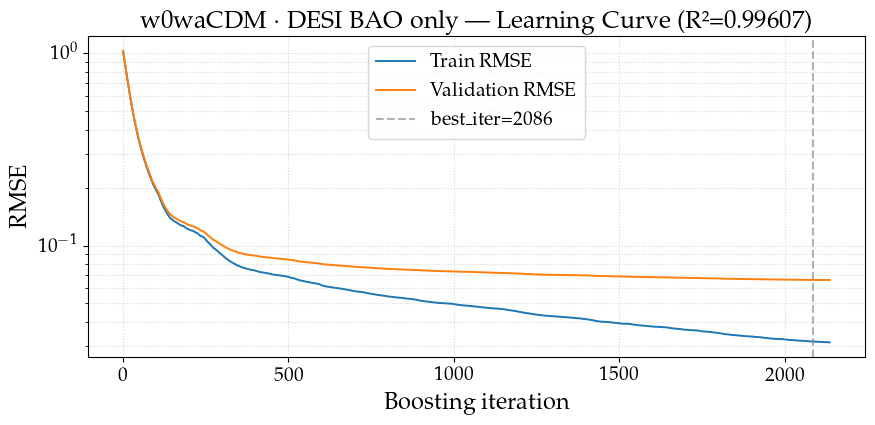

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_bao_shap_beeswarm.png


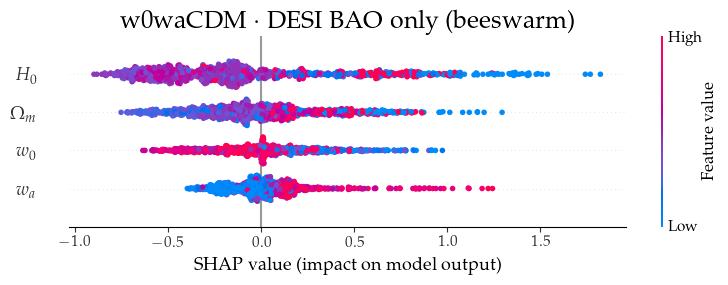

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_bao_shap_bar.png


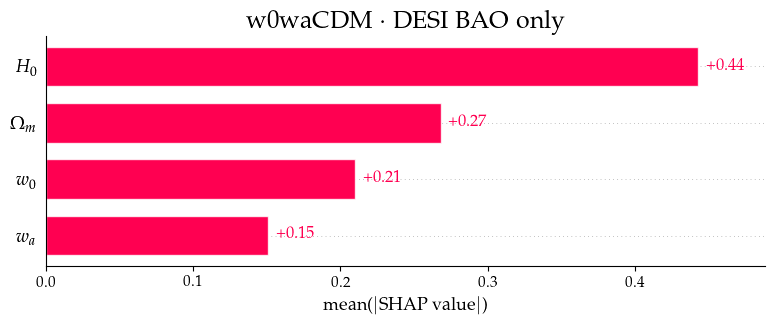

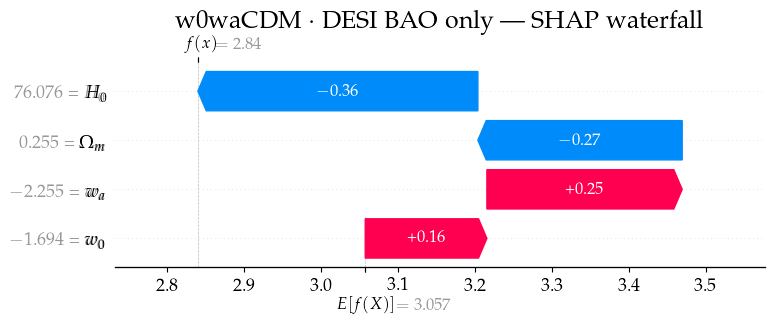

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_bao_shap_Om.png


<Figure size 640x480 with 0 Axes>

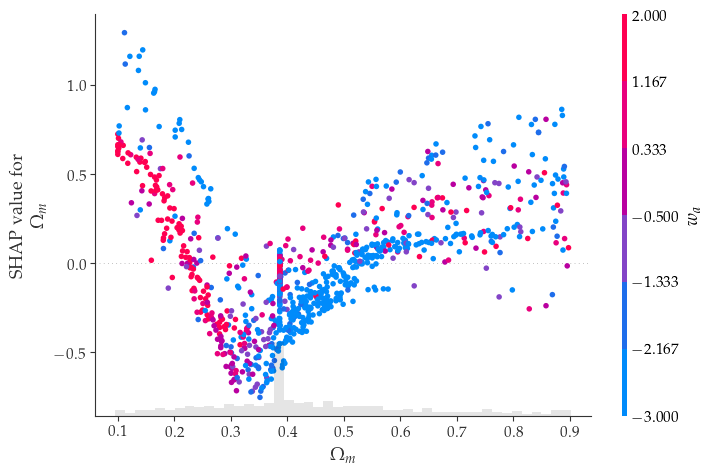

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_bao_shap_H0.png


<Figure size 640x480 with 0 Axes>

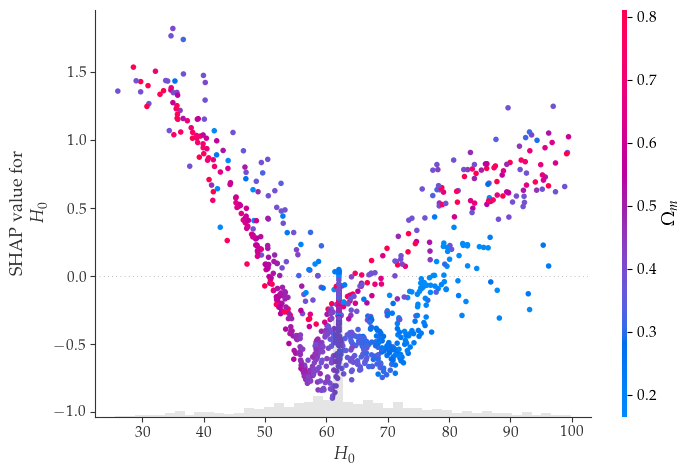

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_bao_shap_w0.png


<Figure size 640x480 with 0 Axes>

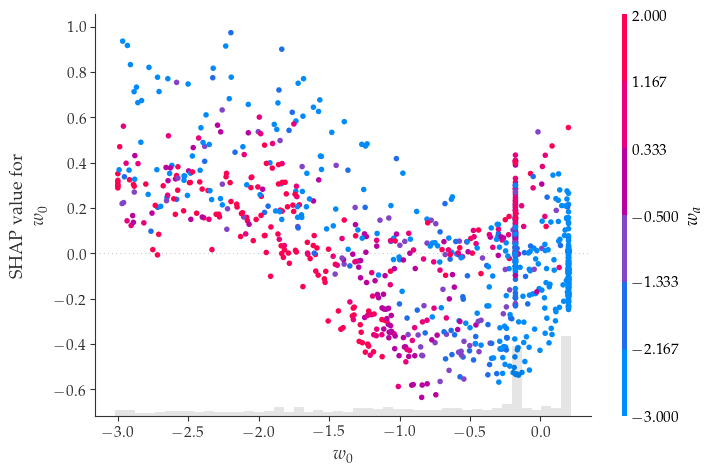

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_bao_shap_wa.png


<Figure size 640x480 with 0 Axes>

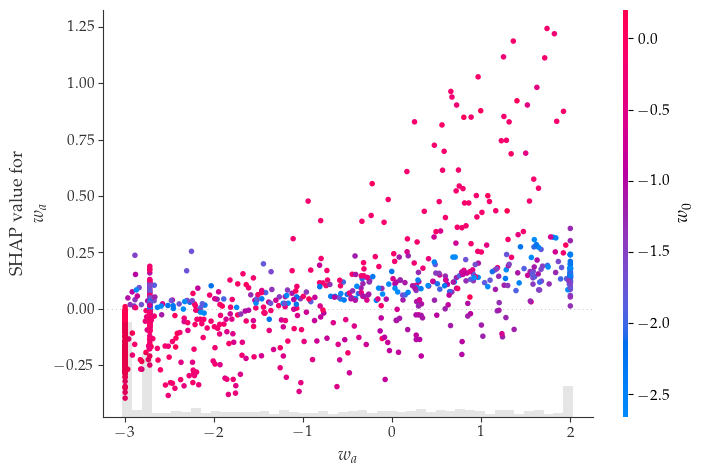


=== w0waCDM · Pantheon+ & DESI BAO ===
  loading cached model: 7_pb_model.ubj
  R2=0.99780 | best_iter=2500 | n_train=273,915 | n_val=48,339


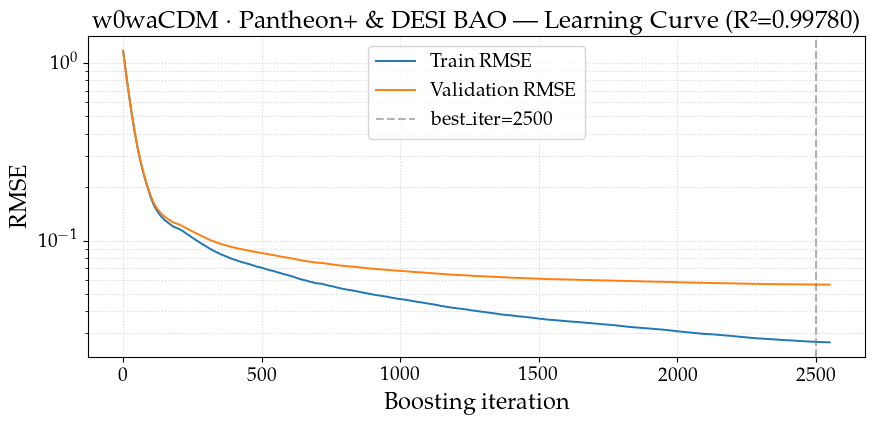

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_pb_shap_beeswarm.png


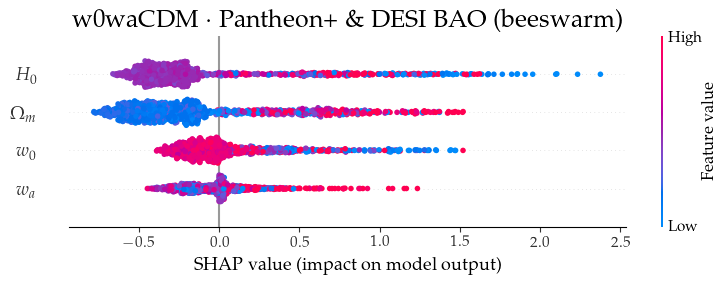

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_pb_shap_bar.png


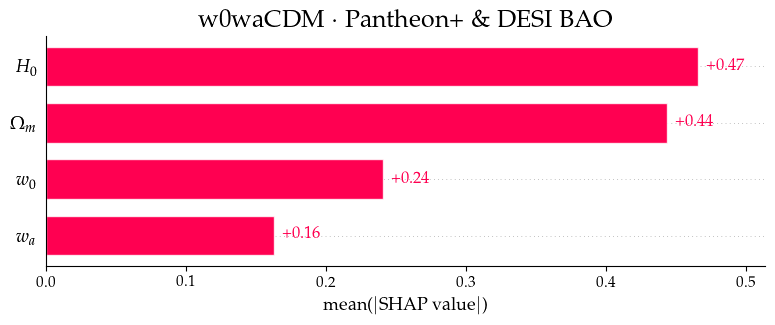

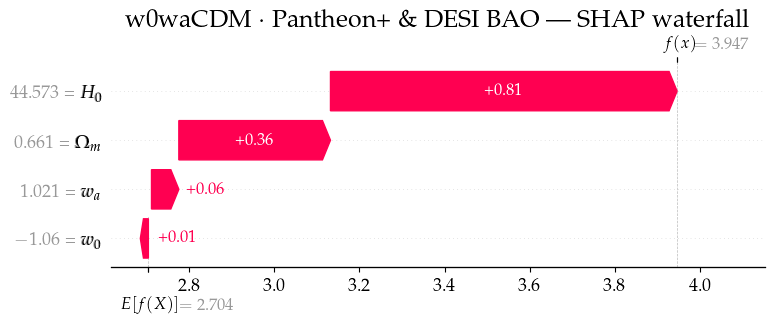

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_pb_shap_Om.png


<Figure size 640x480 with 0 Axes>

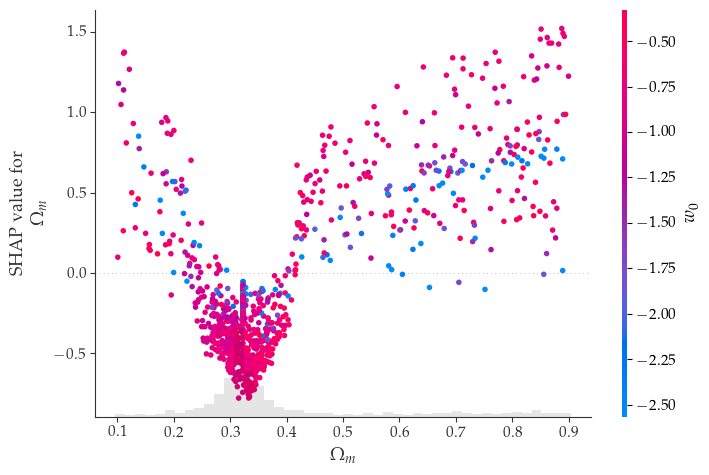

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_pb_shap_H0.png


<Figure size 640x480 with 0 Axes>

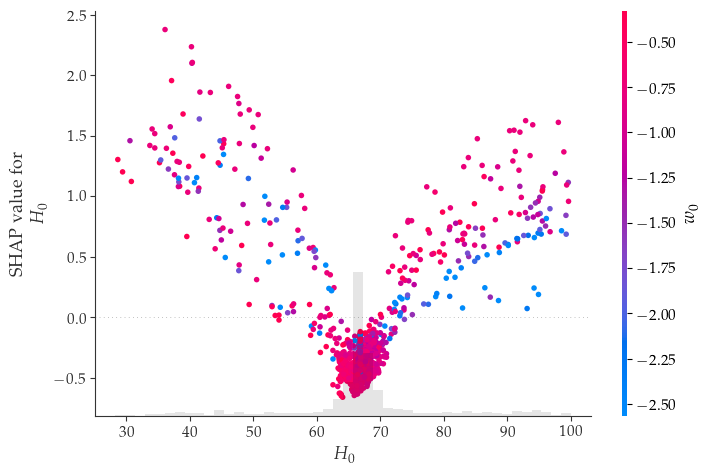

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_pb_shap_w0.png


<Figure size 640x480 with 0 Axes>

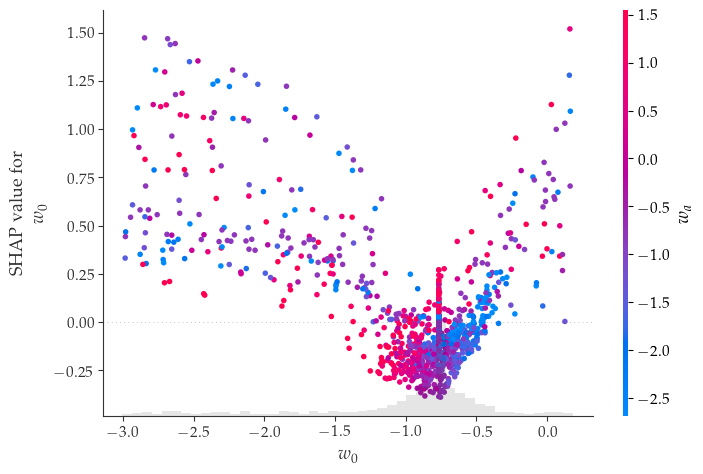

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_pb_shap_wa.png


<Figure size 640x480 with 0 Axes>

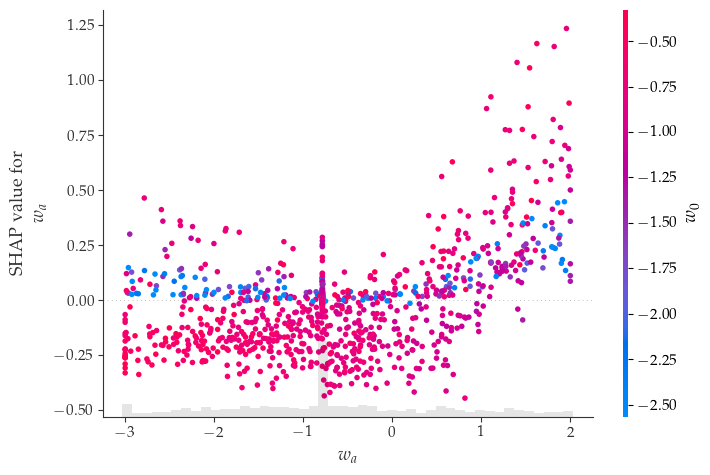


=== w0waCDM · Pantheon+ & DESI BAO & CMB ===
  loading cached model: 7_pbc_model.ubj
  R2=0.99903 | best_iter=1392 | n_train=331,245 | n_val=58,455


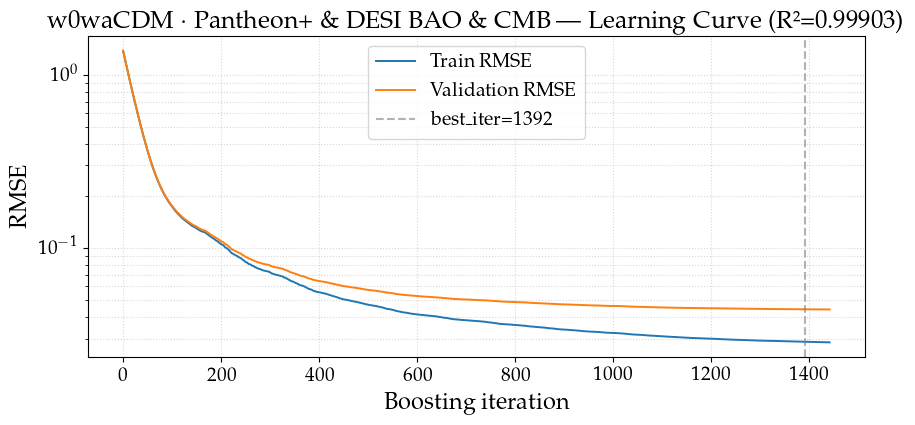

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_pbc_shap_beeswarm.png


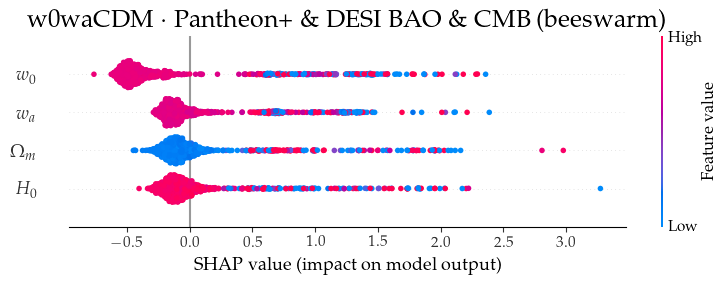

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_pbc_shap_bar.png


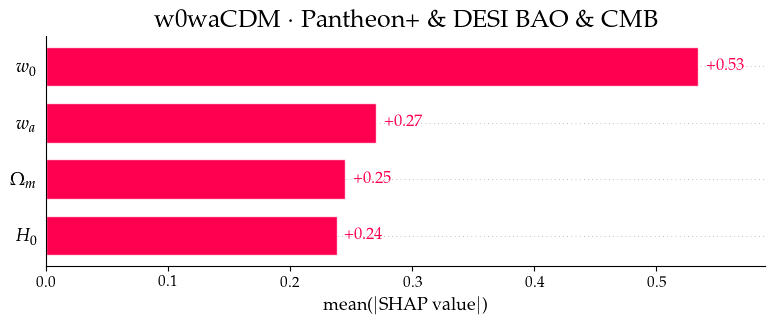

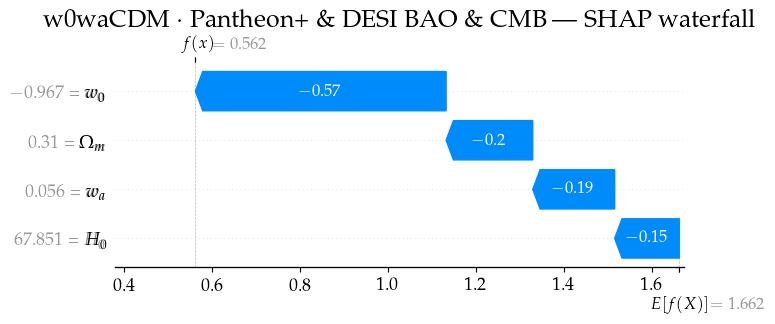

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_pbc_shap_Om.png


<Figure size 640x480 with 0 Axes>

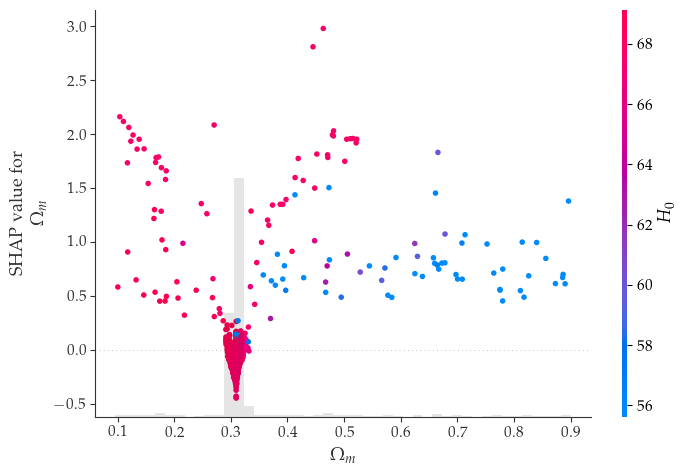

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_pbc_shap_H0.png


<Figure size 640x480 with 0 Axes>

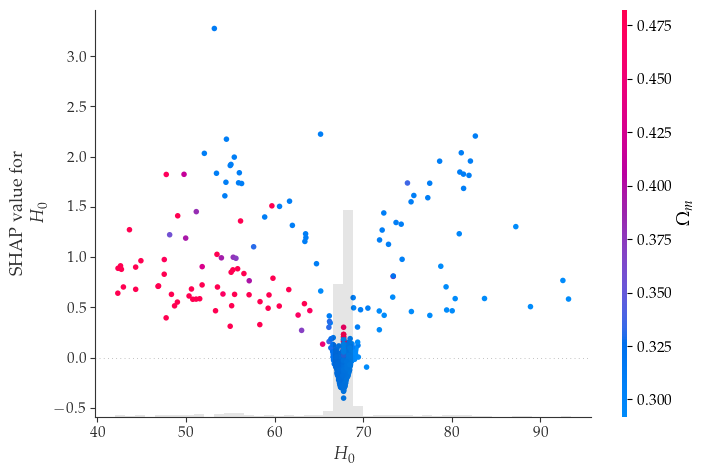

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_pbc_shap_w0.png


<Figure size 640x480 with 0 Axes>

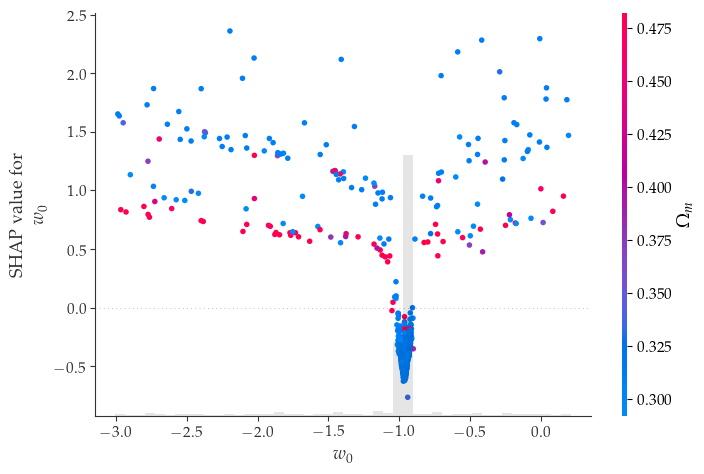

  saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_pbc_shap_wa.png


<Figure size 640x480 with 0 Axes>

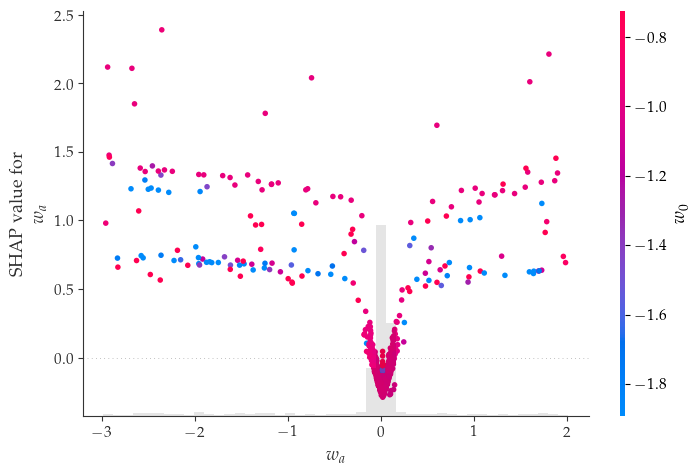

In [8]:
print(f'=== {TITLE_BAO} ===')
model_bao, info_bao, shap_v_bao, X_s_bao = train_and_shap(df_bao, FEATURES_4, SECTION_BAO, title=TITLE_BAO)

print(f'\n=== {TITLE_PB} ===')
model_pb, info_pb, shap_v_pb, X_s_pb = train_and_shap(df_pb, FEATURES_4, SECTION_PB, title=TITLE_PB)

print(f'\n=== {TITLE_PBC} ===')
model_pbc, info_pbc, shap_v_pbc, X_s_pbc = train_and_shap(df_pbc, FEATURES_4, SECTION_PBC, title=TITLE_PBC)

## Section 3 — ML MCMC (all 3 scenarios)

  [ML] Using 500 trees for MCMC
  proposal_cov: Hessian covariance accepted — skipping diagonal phase


/home/aleja/repos/PhysicsML/CosmoML/.venv/lib/python3.14/site-packages/xgboost/core.py:751: UserWarning: [21:15:07] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


  step   200/10000  |  430 it/s  |  ETA 23s  |  acc 0.14  |  multivar
  step   400/10000  |  427 it/s  |  ETA 22s  |  acc 0.14  |  multivar
  step   600/10000  |  414 it/s  |  ETA ≤0s  |  acc 0.14  |  τ=28.3  ESS=3624/10000  |  multivar
  step   800/10000  |  410 it/s  |  ETA ≤1s  |  acc 0.14  |  τ=65.0  ESS=4729/10000  |  multivar
  step  1000/10000  |  302 it/s  |  ETA ≤1s  |  acc 0.13  |  τ=67.3  ESS=7602/10000  |  multivar
  step  1200/10000  |  311 it/s  |  ETA ≤3s  |  acc 0.13  |  τ=153.5  ESS=4669/10000  |  multivar
  step  1400/10000  |  317 it/s  |  ETA ≤1s  |  acc 0.13  |  τ=113.5  ESS=8122/10000  |  multivar
  step  1600/10000  |  319 it/s  |  ETA ≤0s  |  acc 0.13  |  τ=104.9  ESS=10736/10000  |  multivar
  done: 5.1s  |  312 it/s  |  acceptance 0.126  |  multivariate proposal
  flat chain: 1,127,424 samples (1024 chains × 1101 steps)  |  τ_max=104.9  |  ESS=10746
  [ML] Done: 5.3s  (1,127,424 samples)
Removed no burn in
  Saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/f

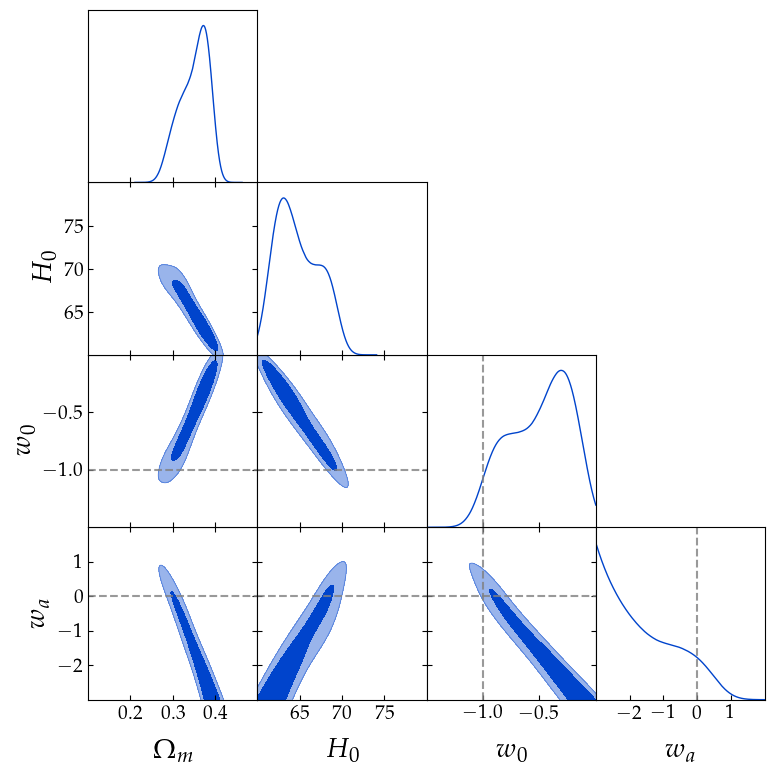

  [ML] Using 500 trees for MCMC
  proposal_cov: Hessian covariance accepted — skipping diagonal phase
  step   200/10000  |  424 it/s  |  ETA 23s  |  acc 0.26  |  multivar
  step   400/10000  |  426 it/s  |  ETA 23s  |  acc 0.27  |  multivar
  step   600/10000  |  411 it/s  |  ETA ≤0s  |  acc 0.24  |  τ=29.1  ESS=3518/10000  |  multivar
  step   800/10000  |  408 it/s  |  ETA ≤1s  |  acc 0.20  |  τ=66.8  ESS=4596/10000  |  multivar
  step  1000/10000  |  323 it/s  |  ETA ≤1s  |  acc 0.18  |  τ=92.8  ESS=5516/10000  |  multivar
  step  1200/10000  |  322 it/s  |  ETA ≤0s  |  acc 0.17  |  τ=72.7  ESS=9866/10000  |  multivar
  step  1400/10000  |  328 it/s  |  ETA ≤0s  |  acc 0.16  |  τ=79.8  ESS=11546/10000  |  multivar
  done: 4.4s  |  322 it/s  |  acceptance 0.158  |  multivariate proposal
  flat chain: 922,624 samples (1024 chains × 901 steps)  |  τ_max=79.8  |  ESS=11559
  [ML] Done: 4.5s  (922,624 samples)
Removed no burn in
  Saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figur

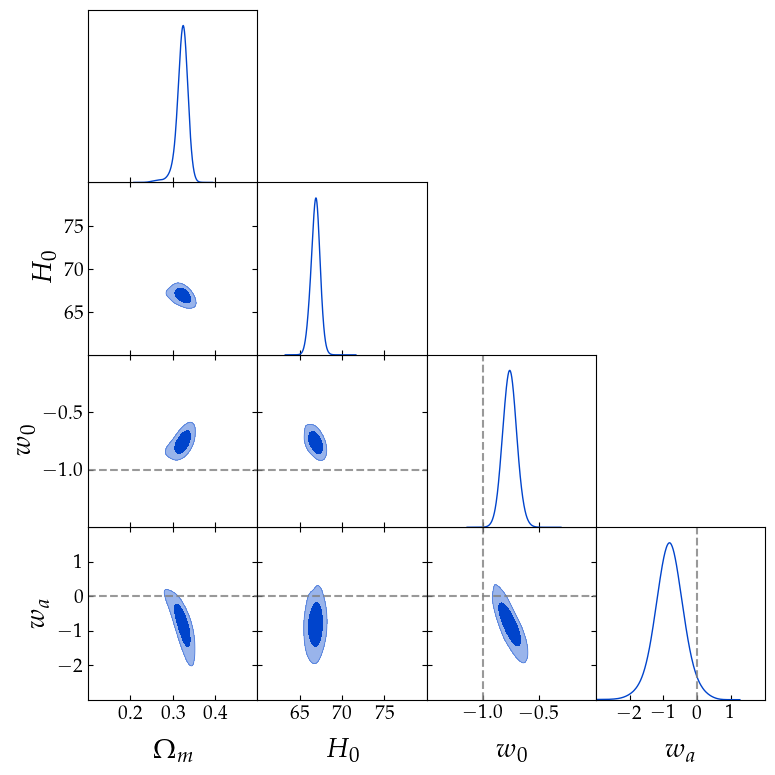

  [ML] Using 500 trees for MCMC
  proposal_cov: Hessian covariance accepted — skipping diagonal phase
  step   200/10000  |  366 it/s  |  ETA 27s  |  acc 0.14  |  multivar
  step   400/10000  |  384 it/s  |  ETA 25s  |  acc 0.14  |  multivar
  step   600/10000  |  369 it/s  |  ETA ≤0s  |  acc 0.12  |  τ=30.0  ESS=3416/3500  |  multivar
  step   800/10000  |  263 it/s  |  ETA ≤0s  |  acc 0.09  |  τ=90.9  ESS=3379/3500  |  multivar
  step  1000/10000  |  279 it/s  |  ETA ≤0s  |  acc 0.07  |  τ=148.8  ESS=3440/3500  |  multivar
  step  1200/10000  |  288 it/s  |  ETA ≤0s  |  acc 0.06  |  τ=205.9  ESS=3481/3500  |  multivar
  step  1400/10000  |  294 it/s  |  ETA ≤0s  |  acc 0.05  |  τ=249.0  ESS=3701/3500  |  multivar
  done: 4.8s  |  289 it/s  |  acceptance 0.053  |  multivariate proposal
  flat chain: 922,624 samples (1024 chains × 901 steps)  |  τ_max=249.0  |  ESS=3705
  [ML] Done: 4.9s  (922,624 samples)
Removed no burn in
  Saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/

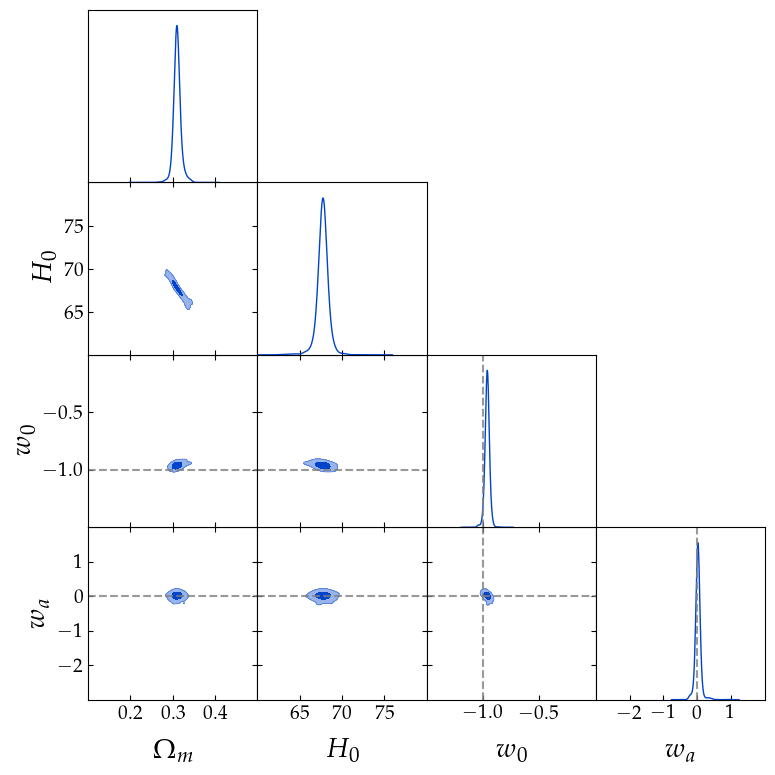

Removed no burn in
Removed no burn in
Removed no burn in
  Saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_ml_3way.png


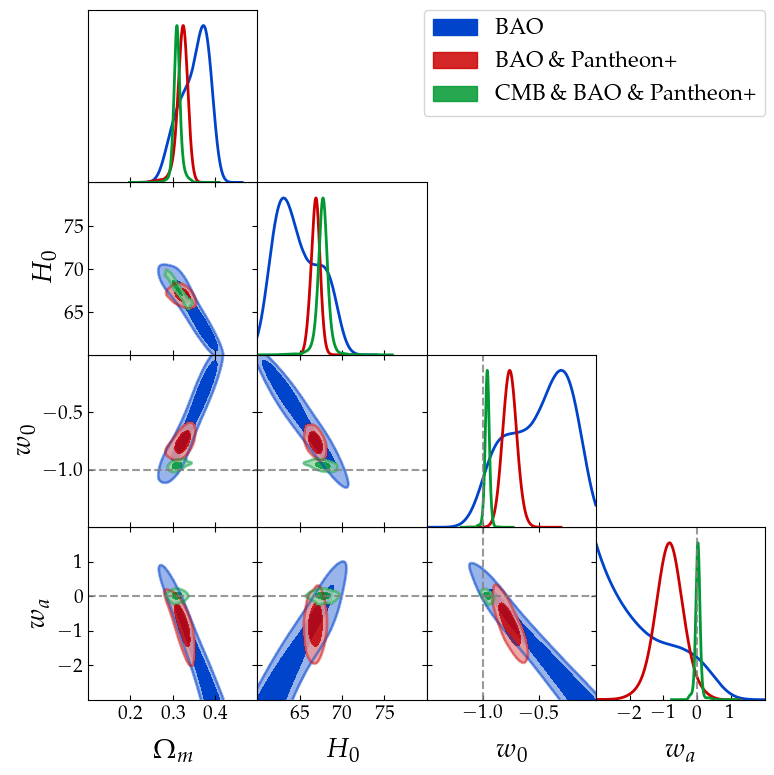

In [9]:
samples_ml_bao, ml_meta_bao = run_mcmc_and_getdist(
    model_bao, FEATURES_4, RANGES_4, REF_BAO, SECTION_BAO,
    labels=LABELS, markers=MARKERS_DE, title=TITLE_BAO, proposal_cov=COV_BAO,
    n_trees_mcmc=ML_MCMC_TREES,
)
samples_ml_pb, ml_meta_pb = run_mcmc_and_getdist(
    model_pb, FEATURES_4, RANGES_4, REF_PB, SECTION_PB,
    labels=LABELS, markers=MARKERS_DE, title=TITLE_PB, proposal_cov=COV_PB,
    n_trees_mcmc=ML_MCMC_TREES,
)
samples_ml_pbc, ml_meta_pbc = run_mcmc_and_getdist(
    model_pbc, FEATURES_4, RANGES_4, REF_PBC, SECTION_PBC,
    labels=LABELS, markers=MARKERS_DE, title=TITLE_PBC, proposal_cov=COV_PBC,
    n_trees_mcmc=ML_MCMC_TREES,ess_target=3500
)

plot_getdist_comparison(
    [samples_ml_bao, samples_ml_pb, samples_ml_pbc],
    ['BAO', 'BAO & Pantheon+', 'CMB & BAO & Pantheon+'],
    FEATURES_4, LABELS,
    markers=MARKERS_DE,
    title='w0waCDM — ML MCMC: 3-scenario comparison',
    save_path=FIGURES_DIR / '7_ml_3way.png',
    filled=[True, True, True], ranges=RANGES_4,
)

## Section 4 — Theory Astropy: ProcessPoolExecutor

Pantheon+ scenarios are skipped: multiprocessing with large likelihoods causes IPC/thread issues on GPU servers. Covered by the CPU back-end (Section 5) and GPU back-end (Section 6).

  [TH-CPU] Running MCMC (1024 chains, 16 cores)...
  proposal_cov: Hessian covariance accepted — skipping diagonal phase
  step   200/10000  |  38 it/s  |  ETA 261s  |  acc 0.15  |  multivar
  step   400/10000  |  38 it/s  |  ETA 254s  |  acc 0.14  |  multivar
  step   600/10000  |  38 it/s  |  ETA ≤5s  |  acc 0.13  |  τ=31.1  ESS=3298/10000  |  multivar
  step   800/10000  |  38 it/s  |  ETA ≤13s  |  acc 0.11  |  τ=80.9  ESS=3796/10000  |  multivar
  step  1000/10000  |  38 it/s  |  ETA ≤21s  |  acc 0.10  |  τ=131.4  ESS=3896/10000  |  multivar
  step  1200/10000  |  38 it/s  |  ETA ≤28s  |  acc 0.09  |  τ=180.9  ESS=3963/10000  |  multivar
  step  1400/10000  |  38 it/s  |  ETA ≤24s  |  acc 0.08  |  τ=184.5  ESS=4994/10000  |  multivar
  step  1600/10000  |  38 it/s  |  ETA ≤24s  |  acc 0.08  |  τ=205.9  ESS=5470/10000  |  multivar
  step  1800/10000  |  38 it/s  |  ETA ≤30s  |  acc 0.07  |  τ=251.3  ESS=5298/10000  |  multivar
  step  2000/10000  |  38 it/s  |  ETA ≤37s  |  acc 0.07

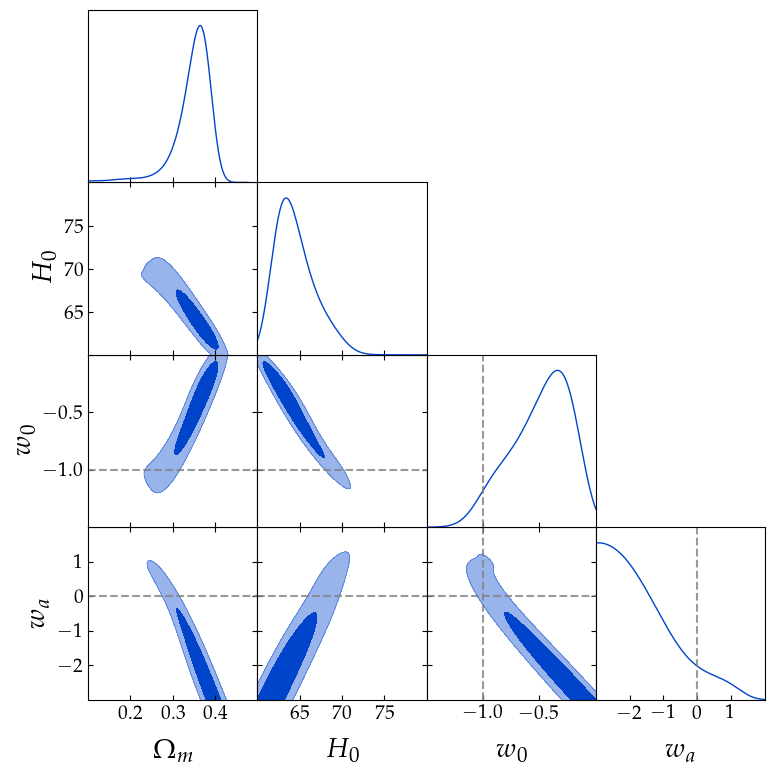

[TH-CPU] panth scenarios: skipped (IPC/thread issues with large likelihoods on GPU server)


In [10]:
samples_cpu_bao, th_cpu_meta_bao = run_theory_mcmc(
    chi2_bao_only, FEATURES_4, RANGES_4, REF_BAO, SECTION_BAO,
    labels=LABELS, markers=MARKERS_DE, title=TITLE_BAO, proposal_cov=COV_BAO,
)
th_cpu_meta_pb  = {'cached': False, 'wall_s': None, 'n_samples': None, 'skipped': True}
th_cpu_meta_pbc = {'cached': False, 'wall_s': None, 'n_samples': None, 'skipped': True}
print('[TH-CPU] panth scenarios: skipped (IPC/thread issues with large likelihoods on GPU server)')

## Section 5 — Theory CPU: vectorized NumPy (batched, all 3 scenarios)

In [11]:
np_fn_bao = make_chi2_numpy_fn(panth=None,  bao=bao)
np_fn_pb  = make_chi2_numpy_fn(panth=panth, bao=bao)
np_fn_pbc = make_chi2_numpy_fn(panth=panth, bao=bao, planck_prior=True)
print('Numpy predict functions ready.')

Numpy predict functions ready.


  [TH-NP] Running MCMC (numpy batched)...
  proposal_cov: Hessian covariance accepted — skipping diagonal phase
  step   200/10000  |  142 it/s  |  ETA 69s  |  acc 0.15  |  multivar
  step   400/10000  |  134 it/s  |  ETA 72s  |  acc 0.14  |  multivar
  step   600/10000  |  127 it/s  |  ETA ≤2s  |  acc 0.13  |  τ=31.1  ESS=3298/10000  |  multivar
  step   800/10000  |  128 it/s  |  ETA ≤4s  |  acc 0.11  |  τ=80.9  ESS=3796/10000  |  multivar
  step  1000/10000  |  129 it/s  |  ETA ≤6s  |  acc 0.10  |  τ=131.4  ESS=3896/10000  |  multivar
  step  1200/10000  |  129 it/s  |  ETA ≤8s  |  acc 0.09  |  τ=180.9  ESS=3963/10000  |  multivar
  step  1400/10000  |  129 it/s  |  ETA ≤7s  |  acc 0.08  |  τ=184.5  ESS=4994/10000  |  multivar
  step  1600/10000  |  129 it/s  |  ETA ≤7s  |  acc 0.08  |  τ=205.9  ESS=5470/10000  |  multivar
  step  1800/10000  |  129 it/s  |  ETA ≤9s  |  acc 0.07  |  τ=251.3  ESS=5298/10000  |  multivar
  step  2000/10000  |  129 it/s  |  ETA ≤11s  |  acc 0.07  |  τ=

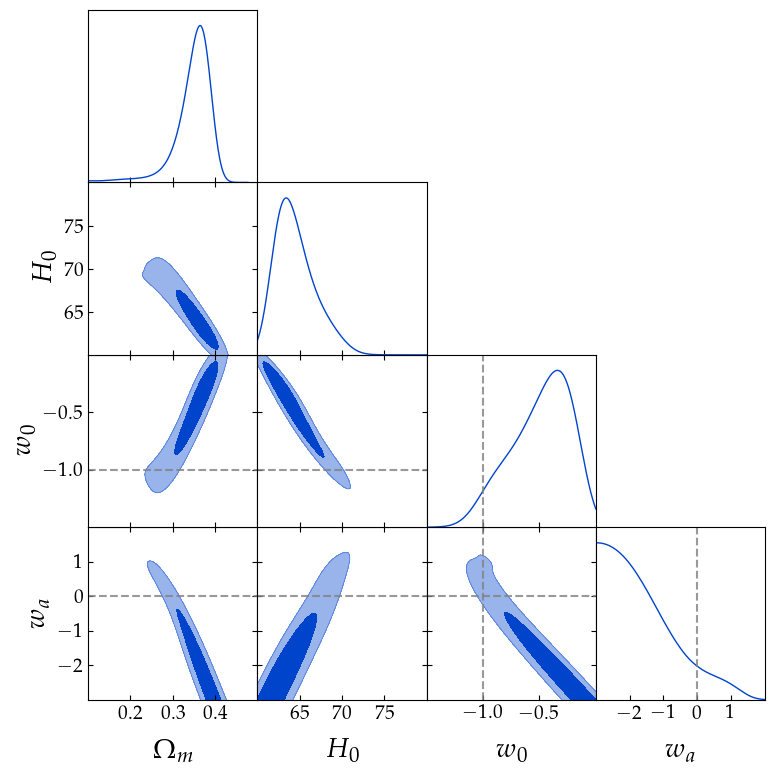

  [TH-NP] Running MCMC (numpy batched)...
  proposal_cov: Hessian covariance accepted — skipping diagonal phase
  step   200/10000  |  9 it/s  |  ETA 1037s  |  acc 0.29  |  multivar
  step   400/10000  |  9 it/s  |  ETA 1024s  |  acc 0.29  |  multivar
  step   600/10000  |  9 it/s  |  ETA ≤21s  |  acc 0.26  |  τ=29.7  ESS=3446/10000  |  multivar
  step   800/10000  |  9 it/s  |  ETA ≤43s  |  acc 0.22  |  τ=70.6  ESS=4349/10000  |  multivar
  step  1000/10000  |  9 it/s  |  ETA ≤33s  |  acc 0.20  |  τ=80.9  ESS=6325/10000  |  multivar
  step  1200/10000  |  9 it/s  |  ETA ≤115s  |  acc 0.18  |  τ=176.0  ESS=4072/10000  |  multivar
  step  1400/10000  |  9 it/s  |  ETA ≤189s  |  acc 0.17  |  τ=263.0  ESS=3505/10000  |  multivar
  step  1600/10000  |  9 it/s  |  ETA ≤188s  |  acc 0.16  |  τ=282.1  ESS=3994/10000  |  multivar
  step  1800/10000  |  9 it/s  |  ETA ≤198s  |  acc 0.16  |  τ=311.1  ESS=4280/10000  |  multivar
  step  2000/10000  |  9 it/s  |  ETA ≤219s  |  acc 0.15  |  τ=349.7

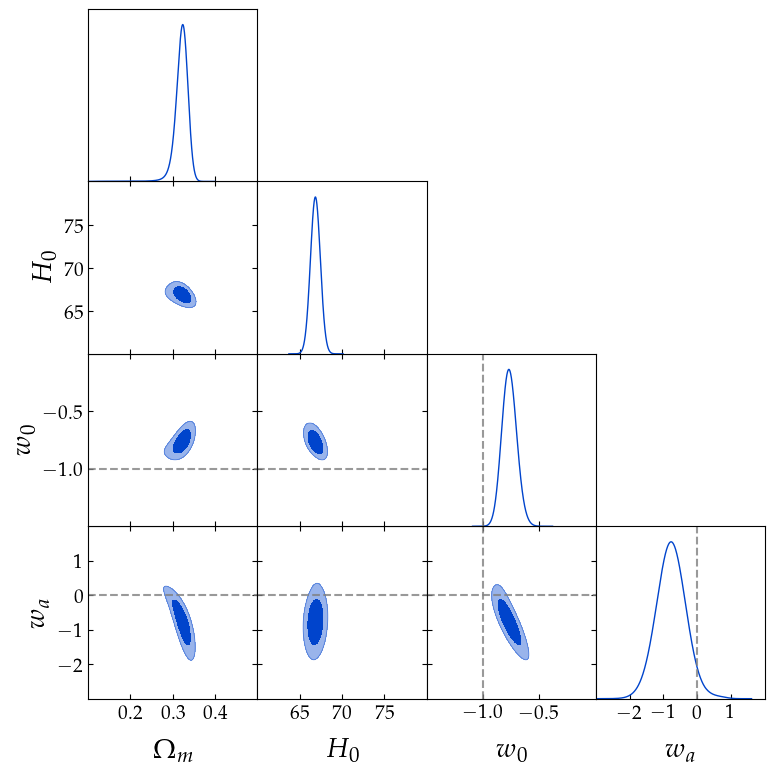

  [TH-NP] Running MCMC (numpy batched)...
  proposal_cov: Hessian covariance accepted — skipping diagonal phase
  step   200/10000  |  9 it/s  |  ETA 1037s  |  acc 0.36  |  multivar
  step   400/10000  |  9 it/s  |  ETA 1023s  |  acc 0.33  |  multivar
  step   600/10000  |  9 it/s  |  ETA ≤2s  |  acc 0.27  |  τ=30.2  ESS=3394/4000  |  multivar
  step   800/10000  |  9 it/s  |  ETA ≤4s  |  acc 0.21  |  τ=85.1  ESS=3610/4000  |  multivar
  step  1000/10000  |  9 it/s  |  ETA ≤7s  |  acc 0.17  |  τ=144.0  ESS=3555/4000  |  multivar
  step  1200/10000  |  9 it/s  |  ETA ≤12s  |  acc 0.14  |  τ=205.8  ESS=3482/4000  |  multivar
  step  1400/10000  |  9 it/s  |  ETA ≤6s  |  acc 0.12  |  τ=242.9  ESS=3793/4000  |  multivar
  step  1600/10000  |  9 it/s  |  ETA ≤1s  |  acc 0.11  |  τ=283.4  ESS=3974/4000  |  multivar
  step  1800/10000  |  9 it/s  |  ETA ≤0s  |  acc 0.10  |  τ=286.2  ESS=4652/4000  |  multivar
  done: 210.4s  |  9 it/s  |  acceptance 0.099  |  multivariate proposal
  flat chai

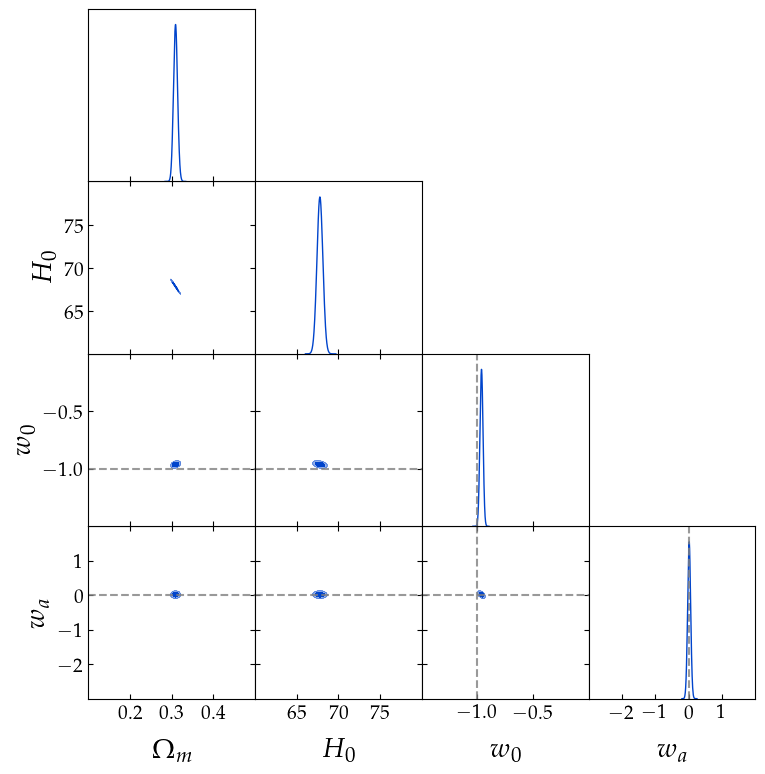

Removed no burn in
Removed no burn in
Removed no burn in
  Saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_theory_np_3way.png


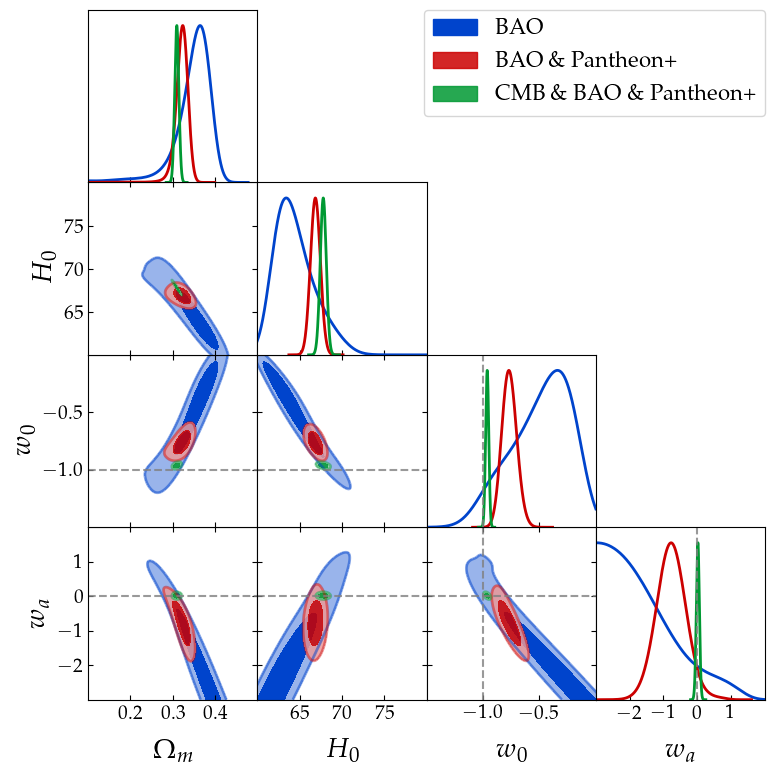

In [12]:
samples_np_bao, th_np_meta_bao = run_theory_mcmc_numpy(
    np_fn_bao, FEATURES_4, RANGES_4, REF_BAO, SECTION_BAO,
    labels=LABELS, markers=MARKERS_DE, title=TITLE_BAO, proposal_cov=COV_BAO,
)
samples_np_pb, th_np_meta_pb = run_theory_mcmc_numpy(
    np_fn_pb, FEATURES_4, RANGES_4, REF_PB, SECTION_PB,
    labels=LABELS, markers=MARKERS_DE, title=TITLE_PB, proposal_cov=COV_PB,
)
samples_np_pbc, th_np_meta_pbc = run_theory_mcmc_numpy(
    np_fn_pbc, FEATURES_4, RANGES_4, REF_PBC, SECTION_PBC,
    labels=LABELS, markers=MARKERS_DE, title=TITLE_PBC, proposal_cov=COV_PBC, ess_target=4_000,
)

plot_getdist_comparison(
    [samples_np_bao, samples_np_pb, samples_np_pbc],
    ['BAO', 'BAO & Pantheon+', 'CMB & BAO & Pantheon+'],
    FEATURES_4, LABELS,
    markers=MARKERS_DE,
    title='w0waCDM — Theory CPU MCMC: 3-scenario comparison',
    save_path=FIGURES_DIR / '7_theory_np_3way.png',
    filled=[True, True, True], ranges=RANGES_4,
)

## Section 6 — Theory GPU: JAX (all 3 scenarios)

JAX/GPU available
Compiling JAX functions (warm-up)...
JAX JIT ready.
  [TH-GPU] Running MCMC (JAX/GPU)...
  proposal_cov: Hessian covariance accepted — skipping diagonal phase
  step   200/10000  |  7 it/s  |  ETA 1315s  |  acc 0.15  |  multivar
  step   400/10000  |  13 it/s  |  ETA 747s  |  acc 0.14  |  multivar
  step   600/10000  |  15 it/s  |  ETA ≤14s  |  acc 0.13  |  τ=31.1  ESS=3298/10000  |  multivar
  step   800/10000  |  18 it/s  |  ETA ≤27s  |  acc 0.11  |  τ=80.9  ESS=3796/10000  |  multivar
  step  1000/10000  |  22 it/s  |  ETA ≤36s  |  acc 0.10  |  τ=131.4  ESS=3896/10000  |  multivar
  step  1200/10000  |  25 it/s  |  ETA ≤43s  |  acc 0.09  |  τ=180.9  ESS=3963/10000  |  multivar
  step  1400/10000  |  28 it/s  |  ETA ≤32s  |  acc 0.08  |  τ=184.5  ESS=4994/10000  |  multivar
  step  1600/10000  |  31 it/s  |  ETA ≤29s  |  acc 0.08  |  τ=205.9  ESS=5470/10000  |  multivar
  step  1800/10000  |  34 it/s  |  ETA ≤34s  |  acc 0.07  |  τ=251.3  ESS=5298/10000  |  multivar

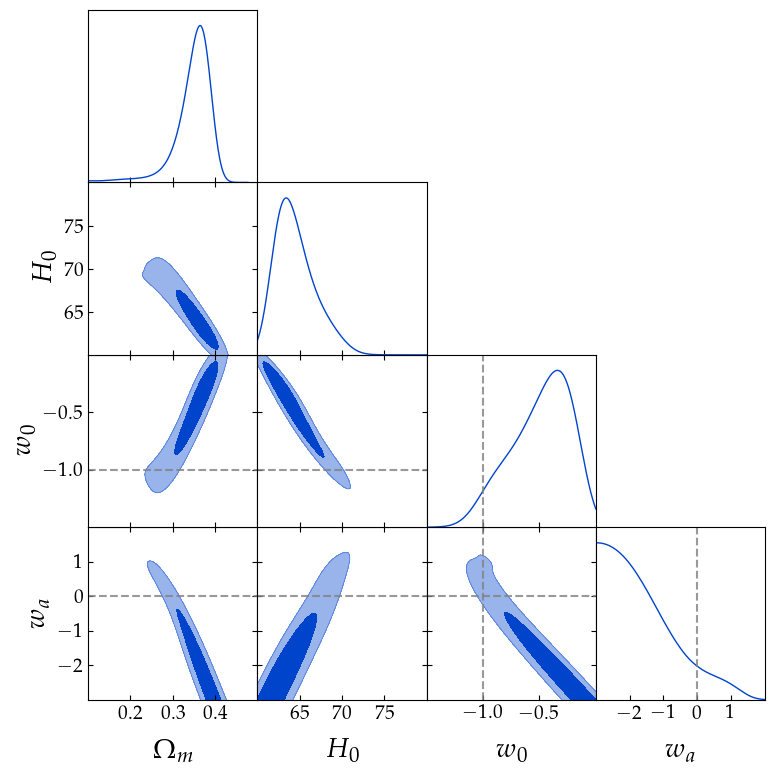

  [TH-GPU] Running MCMC (JAX/GPU)...
  proposal_cov: Hessian covariance accepted — skipping diagonal phase
  step   200/10000  |  8 it/s  |  ETA 1161s  |  acc 0.29  |  multivar
  step   400/10000  |  14 it/s  |  ETA 688s  |  acc 0.29  |  multivar
  step   600/10000  |  18 it/s  |  ETA ≤11s  |  acc 0.26  |  τ=29.7  ESS=3446/10000  |  multivar
  step   800/10000  |  21 it/s  |  ETA ≤19s  |  acc 0.22  |  τ=70.6  ESS=4349/10000  |  multivar
  step  1000/10000  |  23 it/s  |  ETA ≤13s  |  acc 0.20  |  τ=80.9  ESS=6325/10000  |  multivar
  step  1200/10000  |  25 it/s  |  ETA ≤41s  |  acc 0.18  |  τ=176.0  ESS=4072/10000  |  multivar
  step  1400/10000  |  26 it/s  |  ETA ≤64s  |  acc 0.17  |  τ=263.0  ESS=3505/10000  |  multivar
  step  1600/10000  |  27 it/s  |  ETA ≤61s  |  acc 0.16  |  τ=282.1  ESS=3994/10000  |  multivar
  step  1800/10000  |  28 it/s  |  ETA ≤62s  |  acc 0.16  |  τ=311.1  ESS=4280/10000  |  multivar
  step  2000/10000  |  29 it/s  |  ETA ≤66s  |  acc 0.15  |  τ=349.7  

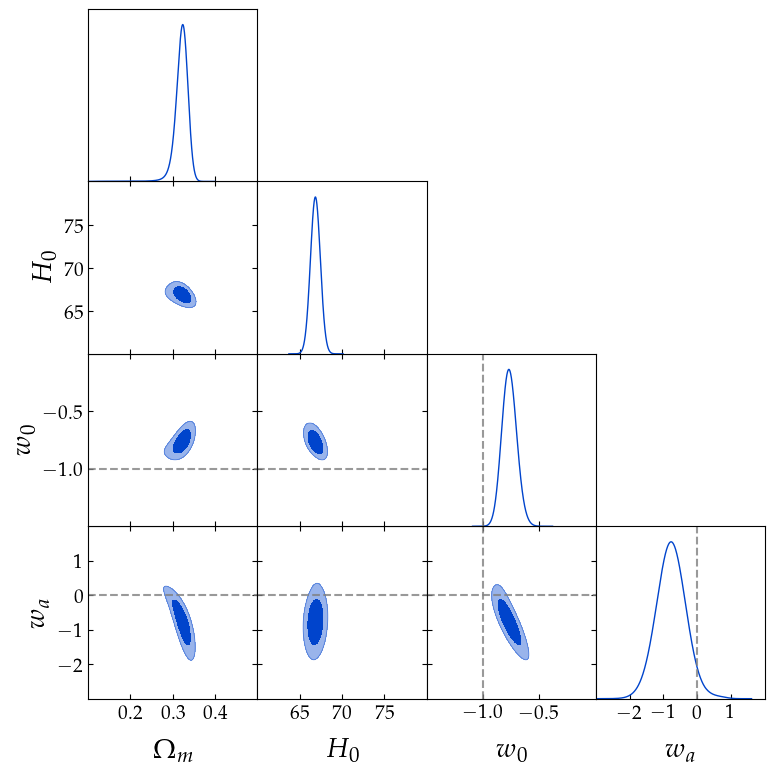

  [TH-GPU] Running MCMC (JAX/GPU)...
  proposal_cov: Hessian covariance accepted — skipping diagonal phase
  step   200/10000  |  40 it/s  |  ETA 246s  |  acc 0.36  |  multivar
  step   400/10000  |  40 it/s  |  ETA 240s  |  acc 0.33  |  multivar
  step   600/10000  |  40 it/s  |  ETA ≤0s  |  acc 0.27  |  τ=30.2  ESS=3394/4000  |  multivar
  step   800/10000  |  40 it/s  |  ETA ≤1s  |  acc 0.21  |  τ=85.1  ESS=3610/4000  |  multivar
  step  1000/10000  |  40 it/s  |  ETA ≤2s  |  acc 0.17  |  τ=144.0  ESS=3555/4000  |  multivar
  step  1200/10000  |  40 it/s  |  ETA ≤3s  |  acc 0.14  |  τ=205.8  ESS=3482/4000  |  multivar
  step  1400/10000  |  40 it/s  |  ETA ≤1s  |  acc 0.12  |  τ=242.9  ESS=3793/4000  |  multivar
  step  1600/10000  |  40 it/s  |  ETA ≤0s  |  acc 0.11  |  τ=283.4  ESS=3974/4000  |  multivar
  step  1800/10000  |  40 it/s  |  ETA ≤0s  |  acc 0.10  |  τ=286.2  ESS=4652/4000  |  multivar
  done: 45.5s  |  40 it/s  |  acceptance 0.099  |  multivariate proposal
  flat cha

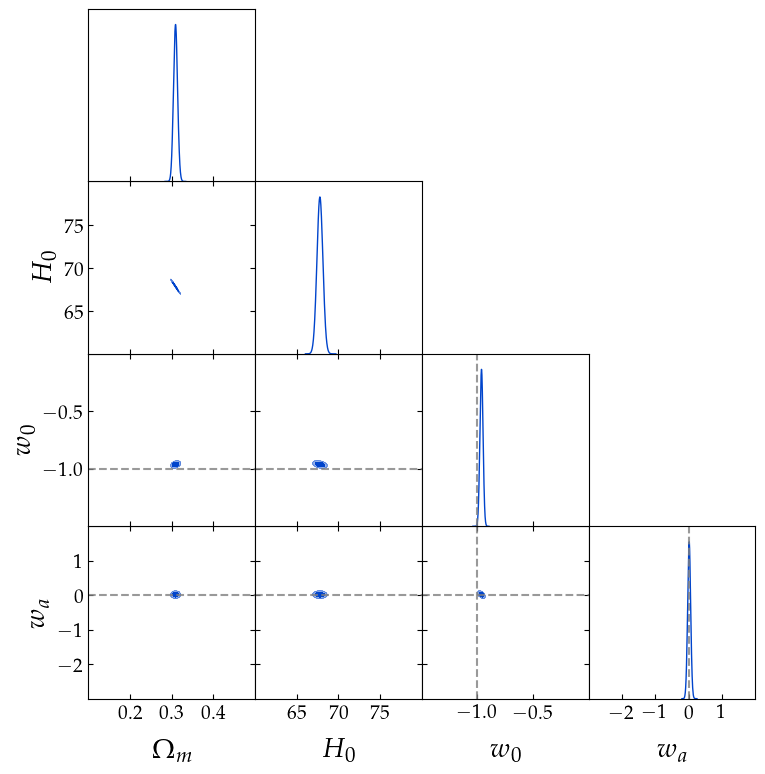

Removed no burn in
Removed no burn in
Removed no burn in
  Saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/figures/07_Benchmark/7_theory_gpu_3way.png


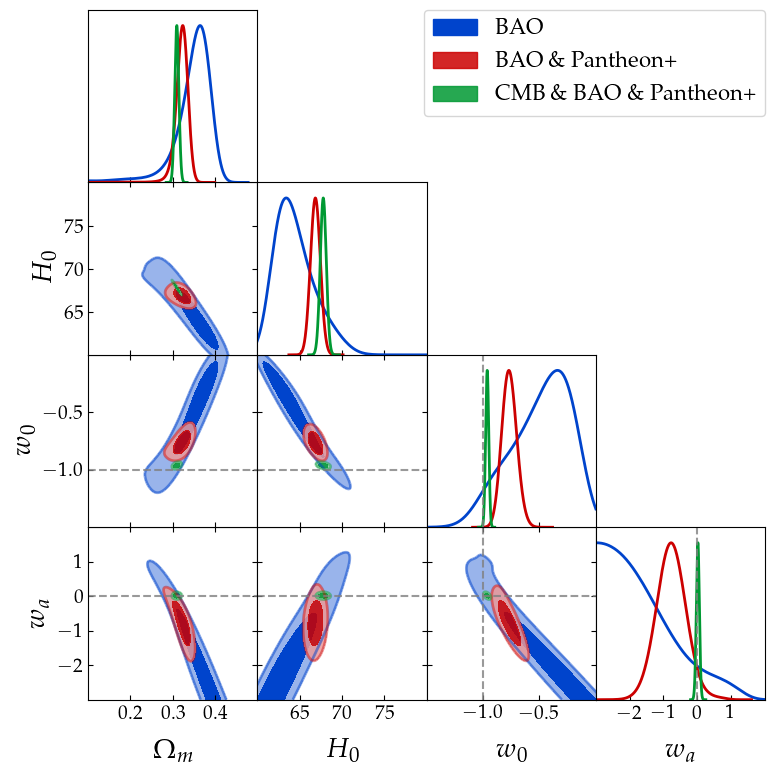

In [13]:
try:
    from cosmoml.theory.jax_theory import make_chi2_gpu_fn as _make_chi2_gpu_fn
    _JAX_THEORY_OK = True
    print('JAX/GPU available')
except ImportError:
    _JAX_THEORY_OK = False
    print('JAX not found — theory GPU benchmark will be skipped')

th_gpu_meta_bao = th_gpu_meta_pb = th_gpu_meta_pbc = None
samples_gpu_bao = samples_gpu_pb = samples_gpu_pbc = None

if not _JAX_THEORY_OK:
    print('[!] JAX not available — skipping Theory GPU sections')
else:
    print('Compiling JAX functions (warm-up)...')
    gpu_fn_bao = _make_chi2_gpu_fn(panth=None,  bao=bao)
    gpu_fn_pb  = _make_chi2_gpu_fn(panth=panth, bao=bao)
    gpu_fn_pbc = _make_chi2_gpu_fn(panth=panth, bao=bao, planck_prior=True)
    print('JAX JIT ready.')

    samples_gpu_bao, th_gpu_meta_bao = run_theory_mcmc_gpu(
        gpu_fn_bao, FEATURES_4, RANGES_4, REF_BAO, SECTION_BAO,
        labels=LABELS, markers=MARKERS_DE, title=TITLE_BAO, proposal_cov=COV_BAO,
    )
    samples_gpu_pb, th_gpu_meta_pb = run_theory_mcmc_gpu(
        gpu_fn_pb, FEATURES_4, RANGES_4, REF_PB, SECTION_PB,
        labels=LABELS, markers=MARKERS_DE, title=TITLE_PB, proposal_cov=COV_PB,
    )
    samples_gpu_pbc, th_gpu_meta_pbc = run_theory_mcmc_gpu(
        gpu_fn_pbc, FEATURES_4, RANGES_4, REF_PBC, SECTION_PBC,
        labels=LABELS, markers=MARKERS_DE, title=TITLE_PBC, proposal_cov=COV_PBC,ess_target=4_000,
    )

    plot_getdist_comparison(
        [samples_gpu_bao, samples_gpu_pb, samples_gpu_pbc],
        ['BAO', 'BAO & Pantheon+', 'CMB & BAO & Pantheon+'],
        FEATURES_4, LABELS,
        markers=MARKERS_DE,
        title='w0waCDM — Theory GPU MCMC: 3-scenario comparison',
        save_path=FIGURES_DIR / '7_theory_gpu_3way.png',
        filled=[True, True, True], ranges=RANGES_4,
    )

## Section 7 — Dataset generation: GPU vs CPU

In [14]:
ds_gpu_meta_bao = ds_gpu_meta_pb = ds_gpu_meta_pbc = None

if not _JAX_THEORY_OK:
    print('[!] JAX not available — skipping dataset GPU benchmark')
else:
    _, ds_gpu_meta_bao = build_dataset_gpu(
        gpu_fn_bao, chi2_bao_only, SECTION_BAO, FEATURES_4, RANGES_4, REF_BAO,
    )
    _, ds_gpu_meta_pb = build_dataset_gpu(
        gpu_fn_pb, chi2_panth_bao, SECTION_PB, FEATURES_4, RANGES_4, REF_PB,
    )
    _, ds_gpu_meta_pbc = build_dataset_gpu(
        gpu_fn_pbc, chi2_panth_bao_cmb, SECTION_PBC, FEATURES_4, RANGES_4, REF_PBC,
    )

    print('\n' + '-' * 86)
    print(f'{"scenario":<22}{"gpu [s]":>10}{"cpu×5k→extrap":>16}'
          f'{"speedup":>10}{"max|Δχ²|":>12}{"mean|Δχ²|":>12}')
    print('-' * 86)
    for name, m in [
        ('bao_only',      ds_gpu_meta_bao),
        ('panth_bao',     ds_gpu_meta_pb),
        ('panth_bao_cmb', ds_gpu_meta_pbc),
    ]:
        if m is None: print(f'  {name}'); continue
        cmp = m.get('comparison', {})
        gpu_s = f"{m['gpu_wall_s']:.1f}s" if m['gpu_wall_s'] else 'cached'
        cpu_s = f"{m['cpu_sample_s']:.1f}s→{m['cpu_extrap_s']:.0f}s"
        spd   = f"{m['speedup']:.1f}x" if m['speedup'] else '-'
        maxd  = f"{cmp['max_abs_diff']:.4f}" if cmp.get('max_abs_diff') else '-'
        meand = f"{cmp['mean_abs_diff']:.4f}" if cmp.get('mean_abs_diff') else '-'
        print(f'{name:<22}{gpu_s:>10}{cpu_s:>16}{spd:>10}{maxd:>12}{meand:>12}')
    print('-' * 86)


  [DS-GPU]  Cache: /home/aleja/repos/PhysicsML/CosmoML/outputs/datasets/7_bao_dataset_gpu.csv (200,000 pts)
  [DS-CPU]  Timing sample 5,000 pts (16 cores)...
  [DS-CPU]  2.9s / 5,000 pts → extrap full: 117s
  [DS-CMP]  max|Δχ²|=32.2205 | mean|Δχ²|=0.3986
  [DS-GPU]  Cache: /home/aleja/repos/PhysicsML/CosmoML/outputs/datasets/7_pb_dataset_gpu.csv (200,000 pts)
  [DS-CPU]  Timing sample 5,000 pts (16 cores)...
  [DS-CPU]  116.7s / 5,000 pts → extrap full: 4669s
  [DS-CMP]  max|Δχ²|=39.7440 | mean|Δχ²|=0.9547
  [DS-GPU]  Cache: /home/aleja/repos/PhysicsML/CosmoML/outputs/datasets/7_pbc_dataset_gpu.csv (200,000 pts)
  [DS-CPU]  Timing sample 5,000 pts (16 cores)...


/home/aleja/repos/PhysicsML/CosmoML/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  [DS-CPU]  117.1s / 5,000 pts → extrap full: 4683s
  [DS-CMP]  max|Δχ²|=39.7390 | mean|Δχ²|=0.9381

--------------------------------------------------------------------------------------
scenario                 gpu [s]   cpu×5k→extrap   speedup    max|Δχ²|   mean|Δχ²|
--------------------------------------------------------------------------------------
bao_only                  cached       2.9s→117s         -     32.2205      0.3986
panth_bao                 cached    116.7s→4669s         -     39.7440      0.9547
panth_bao_cmb             cached    117.1s→4683s         -     39.7390      0.9381
--------------------------------------------------------------------------------------


## Timings — summary table & JSON

Reference results (paper): the surrogate completes each posterior run in
4.8–7.4 s, i.e. 3.6–22.4× faster than the vectorized-NumPy CPU back-end and
7.2–12.1× faster than the exact JAX GPU kernel — and all back-ends produce
statistically identical posteriors, which is the point of this notebook.

Two competing effects shape the table:

- The emulator's per-evaluation cost is essentially independent of the dataset
  (a forward pass through the trees does not depend on the number of
  observables), whereas the exact χ² scales with the data. Hence the speed-up
  over the CPU back-end grows from ~4× (13 BAO points) to ≳20× (~1700 SNe).
- The exact GPU kernel behaves oppositely at small data volume: for BAO-only
  its fixed kernel-launch and host–device-transfer overhead dominates, so it
  is slower than the vectorized CPU code; for the heavy Pantheon+ likelihood
  the overhead is amortised and the GPU wins.

Because every chain runs to a fixed effective-sample-size target rather than a
fixed number of steps, wall-clock time also tracks mixing speed: the tightly
CMB-constrained fit converges in fewer steps, so +CMB is cheaper than
BAO+Pantheon+ despite containing more data.

In [15]:
def _speedup(ml_m, th_m):
    w_ml = (ml_m or {}).get('wall_s')
    w_th = (th_m or {}).get('wall_s')
    return round(w_th / w_ml, 2) if (w_ml and w_th) else None

def _skip(m):
    return m if m is not None else {'wall_s': None, 'n_samples': None, 'cached': True}

timings = {
    'ml_engine':         'RWMH 1024 chains, XGBoost GPU booster (LogChi2)',
    'theory_cpu_engine': 'RWMH 1024 chains, ProcessPoolExecutor exact chi2',
    'theory_np_engine':  'RWMH 1024 chains, numpy batched exact chi2',
    'theory_gpu_engine': 'RWMH 1024 chains, JAX vmap GPU exact chi2',
    'common': {'n_chains': 1024, 'n_steps_cap': 10_000, 'burn_in': 500, 'seed': 42, 'ess_target': 10_000},
    'runs': {
        'bao_only':      {'ml': ml_meta_bao,  'theory_cpu': th_cpu_meta_bao,  'theory_np': th_np_meta_bao,  'theory_gpu': _skip(th_gpu_meta_bao),  'speedup_np_vs_ml': _speedup(ml_meta_bao,  th_np_meta_bao),  'speedup_gpu_vs_ml': _speedup(ml_meta_bao,  _skip(th_gpu_meta_bao))},
        'panth_bao':     {'ml': ml_meta_pb,   'theory_cpu': th_cpu_meta_pb,   'theory_np': th_np_meta_pb,   'theory_gpu': _skip(th_gpu_meta_pb),   'speedup_np_vs_ml': _speedup(ml_meta_pb,   th_np_meta_pb),   'speedup_gpu_vs_ml': _speedup(ml_meta_pb,   _skip(th_gpu_meta_pb))},
        'panth_bao_cmb': {'ml': ml_meta_pbc,  'theory_cpu': th_cpu_meta_pbc,  'theory_np': th_np_meta_pbc,  'theory_gpu': _skip(th_gpu_meta_pbc),  'speedup_np_vs_ml': _speedup(ml_meta_pbc,  th_np_meta_pbc),  'speedup_gpu_vs_ml': _speedup(ml_meta_pbc,  _skip(th_gpu_meta_pbc))},
    },
}

timings_path = CHAINS_DIR / 'timings.json'
with open(timings_path, 'w') as f:
    json.dump(timings, f, indent=2)
print(f'Timings saved: {timings_path}\n')

def _fs(m):
    if m is None: return '-'
    if m.get('skipped'): return 'skipped'
    v = m.get('wall_s')
    return f'{v:.1f}s' if v is not None else '-'
def _fsp(v): return f'{v:.1f}x' if v is not None else '-'

rows = [
    ('bao_only',      ml_meta_bao,  th_cpu_meta_bao,  th_np_meta_bao,  th_gpu_meta_bao),
    ('panth_bao',     ml_meta_pb,   th_cpu_meta_pb,   th_np_meta_pb,   th_gpu_meta_pb),
    ('panth_bao_cmb', ml_meta_pbc,  th_cpu_meta_pbc,  th_np_meta_pbc,  th_gpu_meta_pbc),
]
print('-' * 100)
print(f'{"section":<18}{"ml [s]":>12}{"astropy [s]":>12}{"cpu [s]":>12}{"gpu [s]":>12}{"×cpu/ml":>10}{"×gpu/ml":>10}')
print('-' * 100)
for name, ml_m, cpu_m, np_m, tg_m in rows:
    tg = _skip(tg_m)
    print(f'{name:<18}{_fs(ml_m):>12}{_fs(cpu_m):>12}{_fs(np_m):>12}{_fs(tg):>12}{_fsp(_speedup(ml_m, np_m)):>10}{_fsp(_speedup(ml_m, tg)):>10}')
print('-' * 100)

Timings saved: /home/aleja/repos/PhysicsML/CosmoML/outputs/chains/07_Benchmark/timings.json

----------------------------------------------------------------------------------------------------
section                 ml [s] astropy [s]     cpu [s]     gpu [s]   ×cpu/ml   ×gpu/ml
----------------------------------------------------------------------------------------------------
bao_only                  5.3s      158.0s       66.3s       96.9s     12.6x     18.3x
panth_bao                 4.5s     skipped      417.5s      112.3s     93.6x     25.2x
panth_bao_cmb             5.0s     skipped      210.6s       46.2s     42.5x      9.3x
----------------------------------------------------------------------------------------------------
